# Handwritten Character Recognition using RNN, LSTM, GRU, BiLSTM, and CNN-LSTM

This notebook is a complete, runnable, PyTorch-based lab implementation for handwritten character recognition on **MNIST** and **EMNIST (balanced)**.

## What this notebook covers

1. Setup, reproducibility, and GPU detection
2. Dataset loading and preprocessing (row-wise and column-wise sequence views)
3. Reusable utilities for training, evaluation, visualization, timing, and efficiency metrics
4. Problem 1: Vanilla RNN (from scratch + `nn.RNN`)
5. Problem 2: LSTM (single-layer + stacked + gate analysis)
6. Problem 3: GRU (depth comparison + efficiency)
7. Problem 4: Bidirectional models (BiLSTM concat/avg + BiGRU)
8. Problem 5: CNN + LSTM hybrids (two architectures) and pure CNN baseline
9. Problem 6: Hyperparameter tuning with regularization and optimization techniques
10. Problem 7: Final model comparison with required plots and analyses

## Runtime note

- The notebook includes a **FAST mode** for practical Colab execution.
- Set `FAST_MODE = False` in the configuration cell for heavier training.

In [1]:
# Setup, dependency check, imports, reproducibility, and device detection
import os
import gc
import copy
import time
import math
import random
import warnings
import pkgutil
import subprocess
import sys
from dataclasses import dataclass
from collections import defaultdict
from itertools import product

warnings.filterwarnings("ignore")

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "tqdm": "tqdm",
    "psutil": "psutil",
    "torch": "torch",
    "torchvision": "torchvision",
}

missing = [pip_name for mod_name, pip_name in required_packages.items() if pkgutil.find_loader(mod_name) is None]
if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil

from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset

import torchvision
from torchvision import datasets, transforms

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


@dataclass
class LabConfig:
    fast_mode: bool = False
    data_root: str = "./data"
    base_batch_size: int = 128
    num_workers: int = 2
    pin_memory: bool = True
    val_ratio: float = 0.1

    # Subset sizes for practical Colab runtime in FAST mode
    mnist_train_max: int = 12000
    mnist_val_max: int = 2000
    mnist_test_max: int = 4000

    emnist_train_max: int = 24000
    emnist_val_max: int = 4000
    emnist_test_max: int = 6000

    epochs_screen: int = 1
    epochs_refine: int = 3
    epochs_tuning: int = 1

    lr_default: float = 1e-3
    weight_decay_default: float = 1e-4
    grad_clip_default: float = 1.0
    early_stopping_patience: int = 3


CONFIG = LabConfig()

if not CONFIG.fast_mode:
    CONFIG.mnist_train_max = None
    CONFIG.mnist_val_max = None
    CONFIG.mnist_test_max = None
    CONFIG.emnist_train_max = None
    CONFIG.emnist_val_max = None
    CONFIG.emnist_test_max = None
    CONFIG.epochs_screen = 2
    CONFIG.epochs_refine = 6
    CONFIG.epochs_tuning = 3

print(CONFIG)

Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
Device: cuda
GPU: Tesla T4
LabConfig(fast_mode=False, data_root='./data', base_batch_size=128, num_workers=2, pin_memory=True, val_ratio=0.1, mnist_train_max=None, mnist_val_max=None, mnist_test_max=None, emnist_train_max=None, emnist_val_max=None, emnist_test_max=None, epochs_screen=2, epochs_refine=6, epochs_tuning=3, lr_default=0.001, weight_decay_default=0.0001, grad_clip_default=1.0, early_stopping_patience=3)


## 1) Dataset Loading and Preprocessing

This section loads **MNIST** and **EMNIST (balanced)**, normalizes images, creates train/validation/test splits, and prepares:

- Sequence loaders (row-wise scanning)
- Sequence loaders (column-wise scanning)
- Image loaders (for CNN and hybrid models)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.2MB/s]
100%|██████████| 562M/562M [00:07<00:00, 77.4MB/s] 


Dataset sizes:
MNIST   | train= 54000 | val=  6000 | test= 10000
EMNIST  | train=101520 | val= 11280 | test= 18800


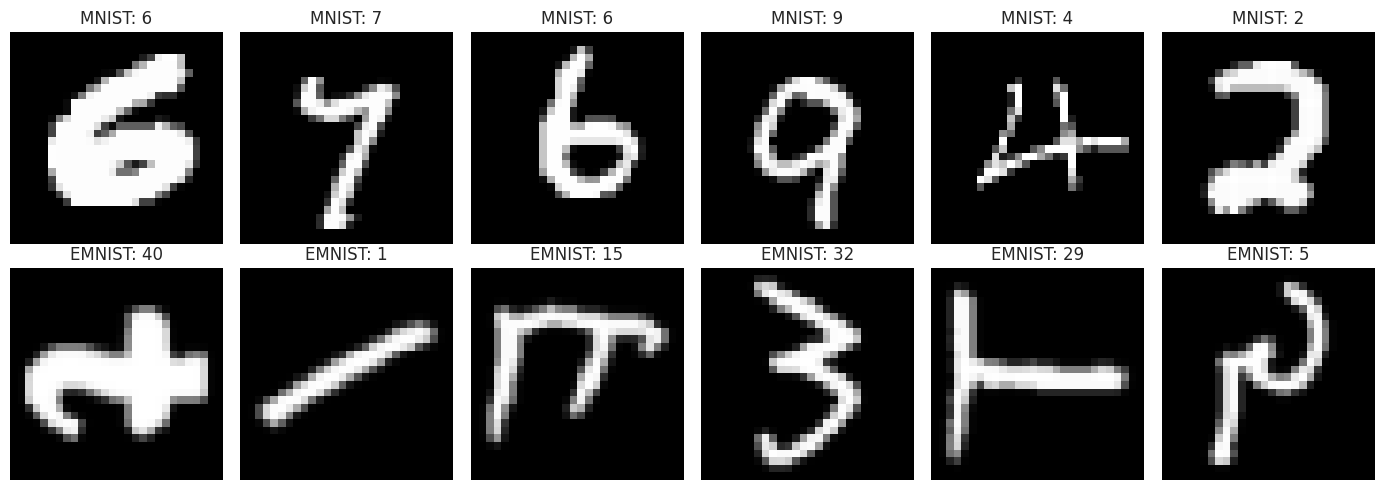

Row sequence shape: torch.Size([28, 28])  | Column sequence shape: torch.Size([28, 28])


In [2]:
class SequenceDataset(Dataset):
    """Wrap an image dataset to return (sequence, label) with row-wise or column-wise scanning."""

    def __init__(self, base_dataset: Dataset, scan_mode: str = "row"):
        assert scan_mode in {"row", "col"}
        self.base_dataset = base_dataset
        self.scan_mode = scan_mode

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]  # img: [1, 28, 28]
        img2d = img.squeeze(0)
        seq = img2d if self.scan_mode == "row" else img2d.t()
        return seq, label


class ImageDataset(Dataset):
    """Identity wrapper to keep naming explicit when using image-based models."""

    def __init__(self, base_dataset: Dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        return self.base_dataset[idx]



def subset_dataset(dataset: Dataset, max_samples: int | None, seed: int = 42) -> Dataset:
    if (max_samples is None) or (max_samples >= len(dataset)):
        return dataset
    gen = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=gen)[:max_samples].tolist()
    return Subset(dataset, indices)



def split_train_val(dataset: Dataset, val_ratio: float, seed: int = 42):
    n_val = int(len(dataset) * val_ratio)
    n_train = len(dataset) - n_val
    gen = torch.Generator().manual_seed(seed)
    train_set, val_set = random_split(dataset, [n_train, n_val], generator=gen)
    return train_set, val_set



def make_loader(dataset: Dataset, batch_size: int, shuffle: bool):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=CONFIG.num_workers,
        pin_memory=CONFIG.pin_memory and torch.cuda.is_available(),
    )



def build_all_loaders_for_dataset(base_splits: dict, batch_size: int):
    train_base = base_splits["train"]
    val_base = base_splits["val"]
    test_base = base_splits["test"]

    loaders = {
        "sequence": {
            "row": {
                "train": make_loader(SequenceDataset(train_base, "row"), batch_size, True),
                "val": make_loader(SequenceDataset(val_base, "row"), batch_size, False),
                "test": make_loader(SequenceDataset(test_base, "row"), batch_size, False),
            },
            "col": {
                "train": make_loader(SequenceDataset(train_base, "col"), batch_size, True),
                "val": make_loader(SequenceDataset(val_base, "col"), batch_size, False),
                "test": make_loader(SequenceDataset(test_base, "col"), batch_size, False),
            },
        },
        "image": {
            "train": make_loader(ImageDataset(train_base), batch_size, True),
            "val": make_loader(ImageDataset(val_base), batch_size, False),
            "test": make_loader(ImageDataset(test_base), batch_size, False),
        },
    }
    return loaders



def load_emnist_balanced_with_fallback(root, transform):
    """Load EMNIST balanced split with retry on the official biometrics mirror.

    Some environments get redirected from the default torchvision URL to an HTML page,
    producing a corrupt `gzip.zip`. This fallback switches to an alternate official URL.
    """
    try:
        train_ds = datasets.EMNIST(root=root, split="balanced", train=True, download=True, transform=transform)
        test_ds = datasets.EMNIST(root=root, split="balanced", train=False, download=True, transform=transform)
        return train_ds, test_ds
    except RuntimeError as err:
        print(f"Default EMNIST download failed: {err}")
        print("Retrying EMNIST download using official biometrics mirror...")

        raw_dir = os.path.join(root, "EMNIST", "raw")
        os.makedirs(raw_dir, exist_ok=True)
        broken_zip = os.path.join(raw_dir, "gzip.zip")
        if os.path.exists(broken_zip):
            try:
                os.remove(broken_zip)
            except OSError:
                pass

        original_url = datasets.EMNIST.url
        original_md5 = datasets.EMNIST.md5
        datasets.EMNIST.url = "https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip"
        datasets.EMNIST.md5 = None

        try:
            train_ds = datasets.EMNIST(root=root, split="balanced", train=True, download=True, transform=transform)
            test_ds = datasets.EMNIST(root=root, split="balanced", train=False, download=True, transform=transform)
        finally:
            datasets.EMNIST.url = original_url
            datasets.EMNIST.md5 = original_md5

        return train_ds, test_ds


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# MNIST
mnist_train_full = datasets.MNIST(root=CONFIG.data_root, train=True, download=True, transform=transform)
mnist_test_full = datasets.MNIST(root=CONFIG.data_root, train=False, download=True, transform=transform)
mnist_train_base, mnist_val_base = split_train_val(mnist_train_full, val_ratio=CONFIG.val_ratio, seed=42)
mnist_train_base = subset_dataset(mnist_train_base, CONFIG.mnist_train_max, seed=42)
mnist_val_base = subset_dataset(mnist_val_base, CONFIG.mnist_val_max, seed=42)
mnist_test_base = subset_dataset(mnist_test_full, CONFIG.mnist_test_max, seed=42)

# EMNIST (balanced) with robust fallback loader
emnist_train_full, emnist_test_full = load_emnist_balanced_with_fallback(CONFIG.data_root, transform)
emnist_train_base, emnist_val_base = split_train_val(emnist_train_full, val_ratio=CONFIG.val_ratio, seed=42)
emnist_train_base = subset_dataset(emnist_train_base, CONFIG.emnist_train_max, seed=42)
emnist_val_base = subset_dataset(emnist_val_base, CONFIG.emnist_val_max, seed=42)
emnist_test_base = subset_dataset(emnist_test_full, CONFIG.emnist_test_max, seed=42)

DATASETS = {
    "MNIST": {
        "splits": {
            "train": mnist_train_base,
            "val": mnist_val_base,
            "test": mnist_test_base,
        },
        "num_classes": 10,
        "class_names": [str(i) for i in range(10)],
    },
    "EMNIST": {
        "splits": {
            "train": emnist_train_base,
            "val": emnist_val_base,
            "test": emnist_test_base,
        },
        "num_classes": 47,
        "class_names": [str(c) for c in emnist_train_full.classes],
    },
}


def get_loaders(dataset_name: str, batch_size: int | None = None):
    if batch_size is None:
        batch_size = CONFIG.base_batch_size
    return build_all_loaders_for_dataset(DATASETS[dataset_name]["splits"], batch_size)


MNIST_LOADERS = get_loaders("MNIST", CONFIG.base_batch_size)
EMNIST_LOADERS = get_loaders("EMNIST", CONFIG.base_batch_size)

print("Dataset sizes:")
for dname, dmeta in DATASETS.items():
    print(
        f"{dname:7s} | train={len(dmeta['splits']['train']):6d} | "
        f"val={len(dmeta['splits']['val']):6d} | test={len(dmeta['splits']['test']):6d}"
    )

# Quick visual sanity check
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    img, y = DATASETS["MNIST"]["splits"]["train"][i]
    axes[0, i].imshow(img.squeeze(0), cmap="gray")
    axes[0, i].set_title(f"MNIST: {y}")
    axes[0, i].axis("off")

for i in range(6):
    img, y = DATASETS["EMNIST"]["splits"]["train"][i]
    axes[1, i].imshow(img.squeeze(0), cmap="gray")
    axes[1, i].set_title(f"EMNIST: {y}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

# Row-wise vs column-wise sequence example
seq_row, _ = SequenceDataset(DATASETS["MNIST"]["splits"]["train"], "row")[0]
seq_col, _ = SequenceDataset(DATASETS["MNIST"]["splits"]["train"], "col")[0]
print("Row sequence shape:", seq_row.shape, " | Column sequence shape:", seq_col.shape)

## 2) Utility Functions

Reusable components for training, evaluation, profiling, and plotting are defined once and reused across all problems.

In [3]:
EXPERIMENT_RESULTS = []
HISTORIES = {}
GRADIENT_TRACKS = {}
BEST_MODELS = {}  # keyed by (dataset, family)


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def evaluate_model(model, loader, criterion, device=DEVICE, return_preds=False):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    all_preds, all_targets = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total += y.size(0)

        if return_preds:
            all_preds.append(preds.detach().cpu())
            all_targets.append(y.detach().cpu())

    out = {
        "loss": total_loss / max(total, 1),
        "acc": total_correct / max(total, 1),
    }
    if return_preds:
        out["preds"] = torch.cat(all_preds).numpy()
        out["targets"] = torch.cat(all_targets).numpy()
    return out



def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device=DEVICE,
    grad_clip=None,
    capture_grads=False,
):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0
    grad_accumulator = defaultdict(list)

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()

        if capture_grads:
            for name, p in model.named_parameters():
                if p.grad is None:
                    continue
                if ("weight_hh" in name) or ("W_hh" in name) or ("cells" in name and "W_hh" in name):
                    grad_accumulator[name].append(p.grad.detach().norm().item())

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total += y.size(0)

    grad_means = {k: float(np.mean(v)) for k, v in grad_accumulator.items()} if capture_grads else {}
    return {
        "loss": total_loss / max(total, 1),
        "acc": total_correct / max(total, 1),
        "grad_norms": grad_means,
    }



def train_model(
    model,
    loaders,
    optimizer,
    criterion,
    epochs,
    scheduler=None,
    grad_clip=None,
    early_stopping_patience=None,
    capture_grads=False,
    verbose=True,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "epoch_time_s": [],
        "grad_norms": [],
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -1.0
    best_epoch = 0
    wait = 0

    t_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        ep_start = time.perf_counter()

        tr = train_one_epoch(
            model,
            loaders["train"],
            criterion,
            optimizer,
            device=DEVICE,
            grad_clip=grad_clip,
            capture_grads=capture_grads,
        )
        va = evaluate_model(model, loaders["val"], criterion, device=DEVICE, return_preds=False)

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(va["loss"])
            else:
                scheduler.step()

        history["train_loss"].append(tr["loss"])
        history["val_loss"].append(va["loss"])
        history["train_acc"].append(tr["acc"])
        history["val_acc"].append(va["acc"])
        history["epoch_time_s"].append(time.perf_counter() - ep_start)
        history["grad_norms"].append(tr["grad_norms"])

        if va["acc"] > best_val_acc:
            best_val_acc = va["acc"]
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            wait = 0
        else:
            wait += 1

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train_loss={tr['loss']:.4f} val_loss={va['loss']:.4f} | "
                f"train_acc={tr['acc']*100:.2f}% val_acc={va['acc']*100:.2f}%"
            )

        if early_stopping_patience is not None and wait >= early_stopping_patience:
            if verbose:
                print(f"Early stopping triggered at epoch {epoch}")
            break

    total_train_time = time.perf_counter() - t_start
    model.load_state_dict(best_state)

    return history, total_train_time, best_epoch


@torch.no_grad()
def measure_inference_time(model, loader, device=DEVICE, num_batches=20):
    model.eval()
    times = []
    seen_samples = 0

    for i, (x, _) in enumerate(loader):
        if i >= num_batches:
            break
        x = x.to(device)

        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = model(x)
        if device.type == "cuda":
            torch.cuda.synchronize()

        dt = time.perf_counter() - t0
        times.append(dt)
        seen_samples += x.size(0)

    if not times:
        return np.nan, np.nan

    batch_ms = 1000.0 * float(np.mean(times))
    sample_ms = 1000.0 * float(np.sum(times) / max(seen_samples, 1))
    return batch_ms, sample_ms



def estimate_flops_from_meta(meta: dict):
    model_type = meta.get("cell_type", "generic")
    seq_len = meta.get("seq_len", 28)
    input_size = meta.get("input_size", 28)
    hidden = meta.get("hidden_size", 128)
    layers = meta.get("num_layers", 1)
    num_classes = meta.get("num_classes", 10)
    bidirectional = meta.get("bidirectional", False)
    cnn_flops = meta.get("cnn_flops", 0)

    dirs = 2 if bidirectional else 1
    gate_mult = {"rnn": 1, "lstm": 4, "gru": 3}

    if model_type in gate_mult:
        g = gate_mult[model_type]
        recurrent = dirs * layers * seq_len * g * 2 * (input_size * hidden + hidden * hidden)
        classifier = 2 * dirs * hidden * num_classes
        return recurrent + classifier + cnn_flops

    if model_type == "cnn":
        return cnn_flops + 2 * hidden * num_classes

    return np.nan



def estimate_memory_mb(model, batch_size: int, meta: dict):
    params = sum(p.numel() for p in model.parameters())
    param_mem = params * 4 / (1024 ** 2)

    # Lightweight activation estimate based on recurrent state footprint.
    seq_len = meta.get("seq_len", 28)
    hidden = meta.get("hidden_size", 128)
    layers = meta.get("num_layers", 1)
    dirs = 2 if meta.get("bidirectional", False) else 1
    activation_mem = batch_size * seq_len * hidden * layers * dirs * 4 / (1024 ** 2)
    return float(param_mem + activation_mem)



def convergence_epoch(val_acc_curve):
    if len(val_acc_curve) == 0:
        return np.nan
    peak = max(val_acc_curve)
    thresh = 0.95 * peak
    for i, v in enumerate(val_acc_curve, start=1):
        if v >= thresh:
            return i
    return len(val_acc_curve)



def plot_training_curves(history, title="Training Curves"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(epochs, history["train_loss"], marker="o", label="Train")
    axes[0].plot(epochs, history["val_loss"], marker="s", label="Validation")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, np.array(history["train_acc"]) * 100, marker="o", label="Train")
    axes[1].plot(epochs, np.array(history["val_acc"]) * 100, marker="s", label="Validation")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()



def plot_confusion(y_true, y_pred, class_names, title="Confusion Matrix", max_classes_to_show=25):
    cm = confusion_matrix(y_true, y_pred)

    # Keep readability when class count is high.
    if len(class_names) > max_classes_to_show:
        idx = np.arange(max_classes_to_show)
        cm = cm[np.ix_(idx, idx)]
        class_names = class_names[:max_classes_to_show]
        title += f" (first {max_classes_to_show} classes)"

    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=False, cmap="Blues", cbar=True)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(ticks=np.arange(len(class_names)) + 0.5, labels=class_names, rotation=90)
    plt.yticks(ticks=np.arange(len(class_names)) + 0.5, labels=class_names, rotation=0)
    plt.tight_layout()
    plt.show()



def display_misclassified_samples(model, loader, class_names, n=20, input_mode="image"):
    model.eval()
    wrong = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(x)
            preds = logits.argmax(dim=1)
            mismatch = preds != y
            if mismatch.any():
                idxs = torch.where(mismatch)[0].tolist()
                for idx in idxs:
                    wrong.append((x[idx].detach().cpu(), int(y[idx].item()), int(preds[idx].item())))
            if len(wrong) >= n:
                break

    n = min(n, len(wrong))
    if n == 0:
        print("No misclassified samples found.")
        return

    cols = 5
    rows = math.ceil(n / cols)
    plt.figure(figsize=(3 * cols, 3 * rows))
    for i in range(n):
        sample, t, p = wrong[i]
        if input_mode == "image":
            img = sample.squeeze(0).numpy()
        elif input_mode == "sequence_row":
            img = sample.numpy()
        else:  # sequence_col
            img = sample.t().numpy()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"T:{class_names[t]} / P:{class_names[p]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()



def tsne_feature_plot(model, loader, class_names, input_mode, max_points=2000, title="t-SNE Feature Projection"):
    model.eval()
    feats, labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            if hasattr(model, "extract_features"):
                f = model.extract_features(x)
            else:
                logits = model(x)
                f = logits

            feats.append(f.detach().cpu())
            labels.append(y)

            if sum(t.size(0) for t in labels) >= max_points:
                break

    feats = torch.cat(feats, dim=0)[:max_points].numpy()
    labels = torch.cat(labels, dim=0)[:max_points].numpy()

    # t-SNE can be expensive; PCA preprocessing speeds convergence.
    if feats.shape[1] > 64:
        u, s, vh = np.linalg.svd(feats - feats.mean(0, keepdims=True), full_matrices=False)
        feats = u[:, :64] * s[:64]

    tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)
    z = tsne.fit_transform(feats)

    plt.figure(figsize=(9, 7))
    scatter = plt.scatter(z[:, 0], z[:, 1], c=labels, cmap="tab20", s=8, alpha=0.7)
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    cbar = plt.colorbar(scatter)
    cbar.set_label("Class index")
    plt.tight_layout()
    plt.show()



def update_best_model(dataset_name, family, result_row, model_obj, input_mode):
    key = (dataset_name, family)
    if (key not in BEST_MODELS) or (result_row["test_acc"] > BEST_MODELS[key]["result"]["test_acc"]):
        BEST_MODELS[key] = {
            "result": result_row,
            "model": copy.deepcopy(model_obj).cpu(),
            "input_mode": input_mode,
        }



def run_experiment(
    model,
    experiment_name,
    family,
    problem,
    dataset_name,
    loaders,
    input_mode,
    optimizer,
    criterion,
    epochs,
    lr,
    weight_decay=0.0,
    scheduler=None,
    grad_clip=None,
    early_stopping=None,
    capture_grads=False,
    meta=None,
    verbose=True,
):
    history, train_time, best_epoch = train_model(
        model=model,
        loaders=loaders,
        optimizer=optimizer,
        criterion=criterion,
        epochs=epochs,
        scheduler=scheduler,
        grad_clip=grad_clip,
        early_stopping_patience=early_stopping,
        capture_grads=capture_grads,
        verbose=verbose,
    )

    test_metrics = evaluate_model(model, loaders["test"], criterion, device=DEVICE, return_preds=True)
    inf_batch_ms, inf_sample_ms = measure_inference_time(model, loaders["test"], device=DEVICE)

    meta = meta or {}
    params = count_parameters(model)
    flops = estimate_flops_from_meta(meta)
    mem_mb = estimate_memory_mb(model, batch_size=loaders["test"].batch_size, meta=meta)
    conv_ep = convergence_epoch(history["val_acc"])

    row = {
        "experiment": experiment_name,
        "problem": problem,
        "dataset": dataset_name,
        "family": family,
        "input_mode": input_mode,
        "epochs_ran": len(history["train_loss"]),
        "best_epoch": best_epoch,
        "train_time_s": train_time,
        "inference_ms_batch": inf_batch_ms,
        "inference_ms_sample": inf_sample_ms,
        "train_loss_last": history["train_loss"][-1],
        "val_loss_last": history["val_loss"][-1],
        "train_acc_last": history["train_acc"][-1],
        "val_acc_last": history["val_acc"][-1],
        "test_loss": test_metrics["loss"],
        "test_acc": test_metrics["acc"],
        "params": params,
        "flops_est": flops,
        "memory_mb_est": mem_mb,
        "lr": lr,
        "weight_decay": weight_decay,
        "convergence_epoch": conv_ep,
    }
    if meta:
        row.update({f"meta_{k}": v for k, v in meta.items()})

    EXPERIMENT_RESULTS.append(row)
    HISTORIES[experiment_name] = history
    if capture_grads:
        GRADIENT_TRACKS[experiment_name] = history["grad_norms"]

    update_best_model(dataset_name, family, row, model, input_mode)

    return row, history, test_metrics


print("Utilities ready.")

Utilities ready.


## 3) Problem 1: Vanilla RNN

### Required implementations
- RNN from scratch (manual recurrent cell)
- RNN using `torch.nn.RNN`

### Experiments
- Layers: 1, 2, 3
- Hidden units: 64, 128, 256
- Scan direction: row-wise vs column-wise

### Outputs in this section
- Accuracy and loss metrics
- Training time comparison
- Gradient magnitude tracking for vanishing gradient analysis

Problem 1 Experiments:   0%|          | 0/36 [00:00<?, ?it/s]

Top Problem 1 configurations:
                   experiment       family    input_mode  test_acc  \
0    P1_RNN-Torch_row_L3_H256    RNN-Torch  sequence_row    0.9572   
1    P1_RNN-Torch_row_L2_H256    RNN-Torch  sequence_row    0.9518   
2    P1_RNN-Torch_row_L1_H256    RNN-Torch  sequence_row    0.9495   
3    P1_RNN-Torch_col_L2_H256    RNN-Torch  sequence_col    0.9426   
4    P1_RNN-Torch_col_L3_H128    RNN-Torch  sequence_col    0.9418   
5    P1_RNN-Torch_row_L2_H128    RNN-Torch  sequence_row    0.9384   
6    P1_RNN-Torch_row_L3_H128    RNN-Torch  sequence_row    0.9357   
7    P1_RNN-Torch_col_L3_H256    RNN-Torch  sequence_col    0.9311   
8     P1_RNN-Torch_row_L3_H64    RNN-Torch  sequence_row    0.9279   
9  P1_RNN-Scratch_col_L1_H256  RNN-Scratch  sequence_col    0.9212   

   train_time_s  params  
0     28.187238  338954  
1     27.348708  207370  
2     25.502662   75786  
3     27.477582  207370  
4     26.920141   87562  
5     26.566211   54538  
6     25.636735  

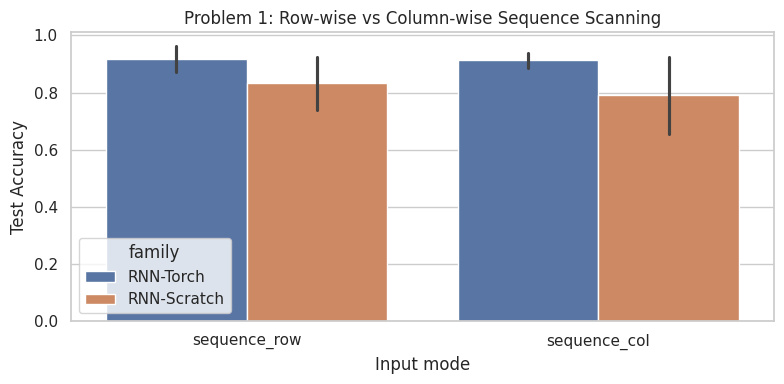

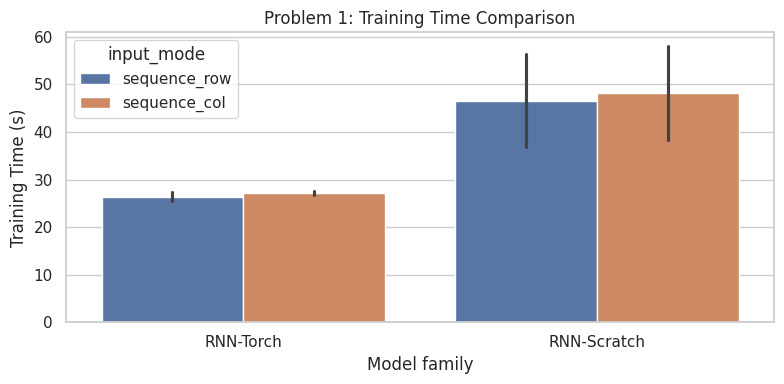

Epoch 01/6 | train_loss=1.0674 val_loss=0.5843 | train_acc=61.98% val_acc=81.40%
Epoch 02/6 | train_loss=0.4921 val_loss=0.3783 | train_acc=84.90% val_acc=88.47%
Epoch 03/6 | train_loss=0.3327 val_loss=0.2806 | train_acc=90.26% val_acc=91.83%
Epoch 04/6 | train_loss=0.2588 val_loss=0.2244 | train_acc=92.84% val_acc=93.93%
Epoch 05/6 | train_loss=0.2155 val_loss=0.2411 | train_acc=94.10% val_acc=93.18%
Epoch 06/6 | train_loss=0.1802 val_loss=0.2197 | train_acc=95.06% val_acc=94.18%


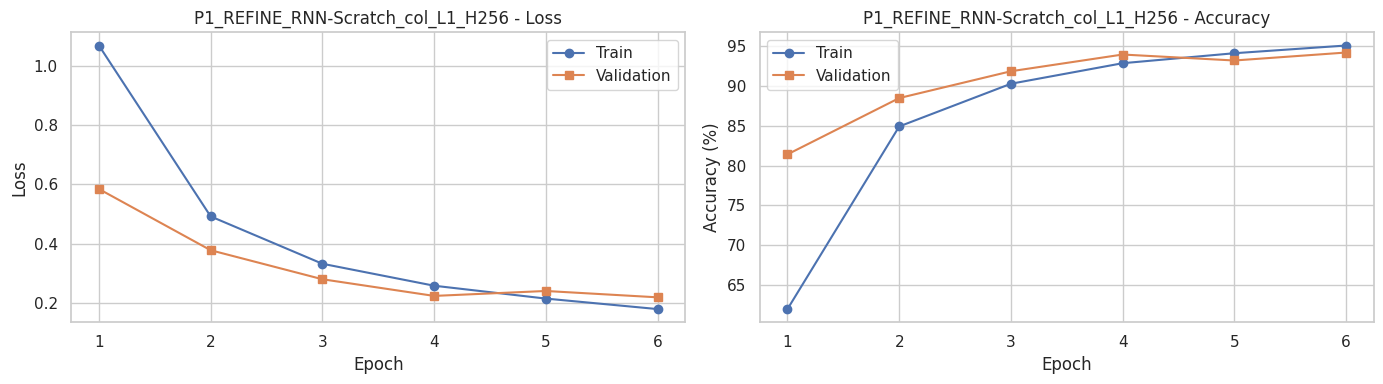

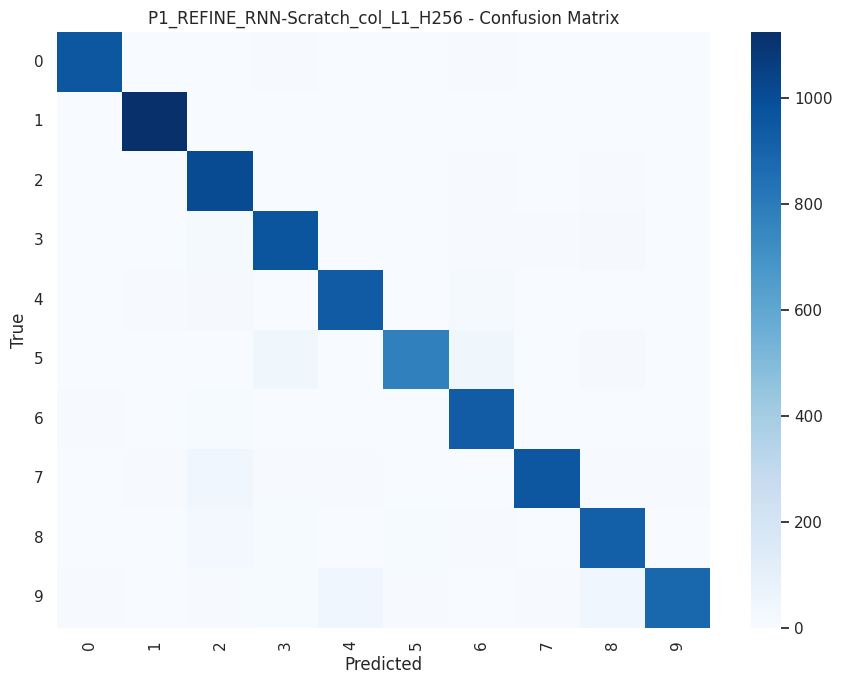

Epoch 01/6 | train_loss=0.5555 val_loss=0.2801 | train_acc=81.47% val_acc=91.97%
Epoch 02/6 | train_loss=0.2288 val_loss=0.1754 | train_acc=93.44% val_acc=95.07%
Epoch 03/6 | train_loss=0.1661 val_loss=0.1854 | train_acc=95.39% val_acc=95.37%
Epoch 04/6 | train_loss=0.1428 val_loss=0.1218 | train_acc=96.04% val_acc=96.70%
Epoch 05/6 | train_loss=0.1213 val_loss=0.1307 | train_acc=96.66% val_acc=96.67%
Epoch 06/6 | train_loss=0.1086 val_loss=0.1096 | train_acc=96.98% val_acc=97.25%


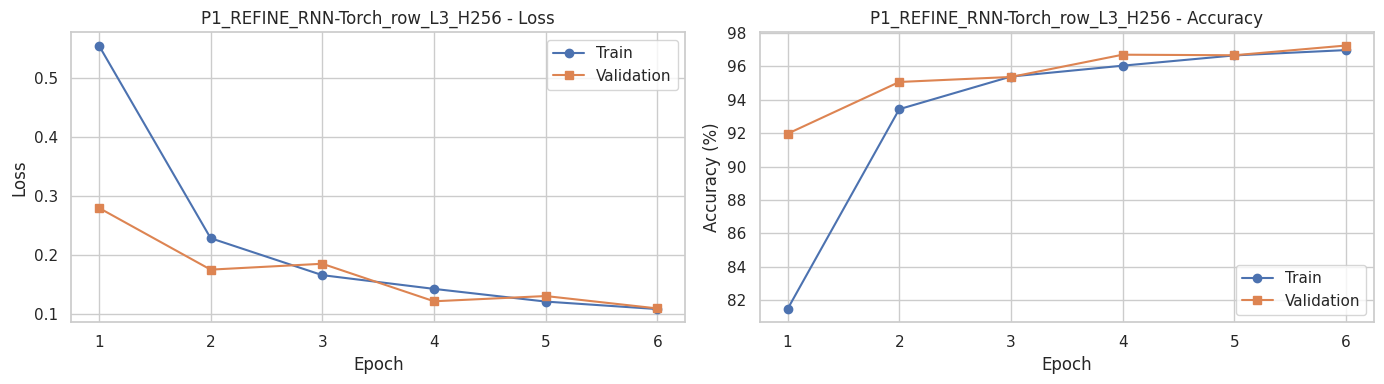

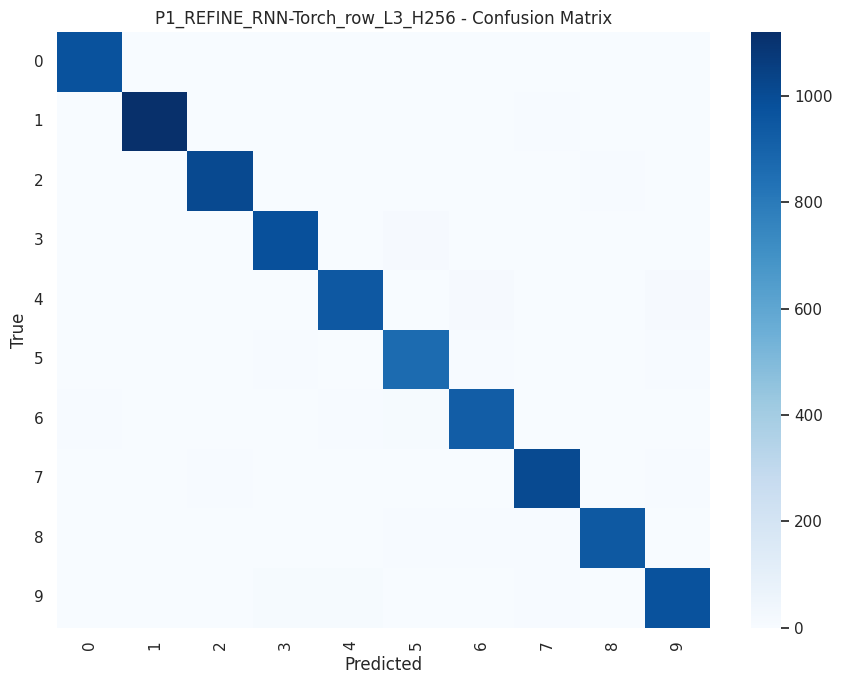

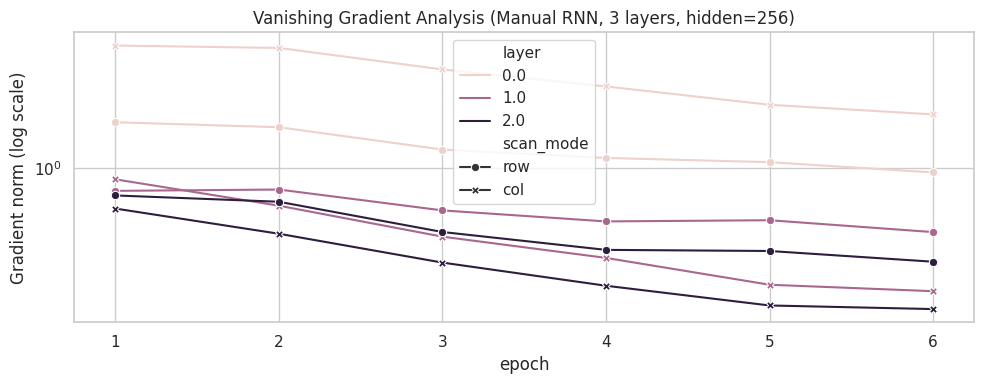

Problem 1 completed.


In [4]:
class ManualRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        self.W_ih = nn.Parameter(torch.randn(hidden_size, input_size) * 0.02)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.02)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x_t, h_prev):
        return torch.tanh(F.linear(x_t, self.W_ih) + F.linear(h_prev, self.W_hh) + self.b_h)


class ManualRNNClassifier(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10, dropout=0.0):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_classes = num_classes

        cells = []
        for l in range(num_layers):
            in_dim = input_size if l == 0 else hidden_size
            cells.append(ManualRNNCell(in_dim, hidden_size))
        self.cells = nn.ModuleList(cells)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: [B, T, F]
        bsz, seq_len, _ = x.shape
        hs = [torch.zeros(bsz, self.hidden_size, device=x.device) for _ in range(self.num_layers)]

        for t in range(seq_len):
            inp = x[:, t, :]
            for l, cell in enumerate(self.cells):
                hs[l] = cell(inp, hs[l])
                inp = hs[l]
                if l < self.num_layers - 1:
                    inp = self.dropout(inp)

        logits = self.fc(hs[-1])
        return logits

    def extract_features(self, x):
        bsz, seq_len, _ = x.shape
        hs = [torch.zeros(bsz, self.hidden_size, device=x.device) for _ in range(self.num_layers)]
        for t in range(seq_len):
            inp = x[:, t, :]
            for l, cell in enumerate(self.cells):
                hs[l] = cell(inp, hs[l])
                inp = hs[l]
        return hs[-1]


class TorchRNNClassifier(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10, dropout=0.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity="tanh",
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, h_n = self.rnn(x)
        feat = h_n[-1]
        return self.fc(feat)

    def extract_features(self, x):
        _, h_n = self.rnn(x)
        return h_n[-1]



def build_p1_model(family, hidden_size, num_layers, num_classes):
    if family == "RNN-Scratch":
        return ManualRNNClassifier(
            input_size=28,
            hidden_size=hidden_size,
            num_layers=num_layers,
            num_classes=num_classes,
            dropout=0.2,
        )
    if family == "RNN-Torch":
        return TorchRNNClassifier(
            input_size=28,
            hidden_size=hidden_size,
            num_layers=num_layers,
            num_classes=num_classes,
            dropout=0.2,
        )
    raise ValueError(f"Unknown family: {family}")


criterion = nn.CrossEntropyLoss()

p1_rows = []
scan_modes = ["row", "col"]
layer_options = [1, 2, 3]
hidden_options = [64, 128, 256]
families = ["RNN-Scratch", "RNN-Torch"]

for scan_mode, num_layers, hidden_size, family in tqdm(
    list(product(scan_modes, layer_options, hidden_options, families)),
    desc="Problem 1 Experiments",
):
    loaders = MNIST_LOADERS["sequence"][scan_mode]

    model = build_p1_model(
        family=family,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_classes=DATASETS["MNIST"]["num_classes"],
    ).to(DEVICE)

    optimizer = optim.Adam(
        model.parameters(),
        lr=CONFIG.lr_default,
        weight_decay=CONFIG.weight_decay_default,
    )

    exp_name = f"P1_{family}_{scan_mode}_L{num_layers}_H{hidden_size}"
    row, hist, _ = run_experiment(
        model=model,
        experiment_name=exp_name,
        family=family,
        problem="P1",
        dataset_name="MNIST",
        loaders=loaders,
        input_mode=f"sequence_{scan_mode}",
        optimizer=optimizer,
        criterion=criterion,
        epochs=CONFIG.epochs_screen,
        lr=CONFIG.lr_default,
        weight_decay=CONFIG.weight_decay_default,
        scheduler=None,
        grad_clip=CONFIG.grad_clip_default,
        early_stopping=None,
        capture_grads=True,
        meta={
            "cell_type": "rnn",
            "seq_len": 28,
            "input_size": 28,
            "hidden_size": hidden_size,
            "num_layers": num_layers,
            "num_classes": DATASETS["MNIST"]["num_classes"],
            "bidirectional": False,
        },
        verbose=False,
    )

    p1_rows.append(row)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

p1_df = pd.DataFrame(p1_rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
print("Top Problem 1 configurations:")
print(p1_df[["experiment", "family", "input_mode", "test_acc", "train_time_s", "params"]].head(10))

# Row-wise vs column-wise comparison
plt.figure(figsize=(8, 4))
sns.barplot(
    data=p1_df,
    x="input_mode",
    y="test_acc",
    hue="family",
    estimator=np.mean,
    errorbar="sd",
)
plt.title("Problem 1: Row-wise vs Column-wise Sequence Scanning")
plt.ylabel("Test Accuracy")
plt.xlabel("Input mode")
plt.tight_layout()
plt.show()

# Training time comparison
plt.figure(figsize=(8, 4))
sns.barplot(
    data=p1_df,
    x="family",
    y="train_time_s",
    hue="input_mode",
    estimator=np.mean,
    errorbar="sd",
)
plt.title("Problem 1: Training Time Comparison")
plt.ylabel("Training Time (s)")
plt.xlabel("Model family")
plt.tight_layout()
plt.show()

# Refine the best config from each RNN family for richer learning curves.
p1_refined = []
for family in families:
    best_row = p1_df[p1_df["family"] == family].iloc[0]
    hidden_size = int(best_row["meta_hidden_size"])
    num_layers = int(best_row["meta_num_layers"])
    scan_mode = "row" if "row" in best_row["input_mode"] else "col"

    loaders = MNIST_LOADERS["sequence"][scan_mode]
    model = build_p1_model(family, hidden_size, num_layers, DATASETS["MNIST"]["num_classes"]).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=CONFIG.lr_default, weight_decay=CONFIG.weight_decay_default)

    exp_name = f"P1_REFINE_{family}_{scan_mode}_L{num_layers}_H{hidden_size}"
    row, hist, test_metrics = run_experiment(
        model=model,
        experiment_name=exp_name,
        family=f"{family}-Refined",
        problem="P1",
        dataset_name="MNIST",
        loaders=loaders,
        input_mode=f"sequence_{scan_mode}",
        optimizer=optimizer,
        criterion=criterion,
        epochs=CONFIG.epochs_refine,
        lr=CONFIG.lr_default,
        weight_decay=CONFIG.weight_decay_default,
        scheduler=None,
        grad_clip=CONFIG.grad_clip_default,
        early_stopping=CONFIG.early_stopping_patience,
        capture_grads=True,
        meta={
            "cell_type": "rnn",
            "seq_len": 28,
            "input_size": 28,
            "hidden_size": hidden_size,
            "num_layers": num_layers,
            "num_classes": DATASETS["MNIST"]["num_classes"],
            "bidirectional": False,
        },
        verbose=True,
    )
    p1_refined.append(row)
    plot_training_curves(hist, title=exp_name)

    preds_eval = evaluate_model(model, loaders["test"], criterion, return_preds=True)
    plot_confusion(
        preds_eval["targets"],
        preds_eval["preds"],
        DATASETS["MNIST"]["class_names"],
        title=f"{exp_name} - Confusion Matrix",
    )

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Vanishing gradient analysis on deep scratch RNN (L=3, H=256)
grad_analysis_rows = []
for scan_mode in ["row", "col"]:
    model = ManualRNNClassifier(input_size=28, hidden_size=256, num_layers=3, num_classes=10, dropout=0.2).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=CONFIG.lr_default, weight_decay=CONFIG.weight_decay_default)

    exp_name = f"P1_GRAD_ANALYSIS_{scan_mode}_L3_H256"
    row, hist, _ = run_experiment(
        model=model,
        experiment_name=exp_name,
        family="RNN-Scratch-GradAnalysis",
        problem="P1",
        dataset_name="MNIST",
        loaders=MNIST_LOADERS["sequence"][scan_mode],
        input_mode=f"sequence_{scan_mode}",
        optimizer=optimizer,
        criterion=criterion,
        epochs=max(3, CONFIG.epochs_refine),
        lr=CONFIG.lr_default,
        weight_decay=CONFIG.weight_decay_default,
        scheduler=None,
        grad_clip=CONFIG.grad_clip_default,
        early_stopping=None,
        capture_grads=True,
        meta={
            "cell_type": "rnn",
            "seq_len": 28,
            "input_size": 28,
            "hidden_size": 256,
            "num_layers": 3,
            "num_classes": 10,
            "bidirectional": False,
        },
        verbose=False,
    )

    for ep, grad_dict in enumerate(hist["grad_norms"], start=1):
        for name, val in grad_dict.items():
            grad_analysis_rows.append(
                {
                    "scan_mode": scan_mode,
                    "epoch": ep,
                    "param": name,
                    "grad_norm": val,
                }
            )

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

grad_df = pd.DataFrame(grad_analysis_rows)
if not grad_df.empty:
    grad_df["layer"] = grad_df["param"].str.extract(r"cells\.(\d+)\.").astype(float)
    plt.figure(figsize=(10, 4))
    sns.lineplot(
        data=grad_df,
        x="epoch",
        y="grad_norm",
        hue="layer",
        style="scan_mode",
        markers=True,
        dashes=False,
    )
    plt.title("Vanishing Gradient Analysis (Manual RNN, 3 layers, hidden=256)")
    plt.yscale("log")
    plt.ylabel("Gradient norm (log scale)")
    plt.tight_layout()
    plt.show()

print("Problem 1 completed.")

## 4) Problem 2: LSTM

### Required implementations
- Single-layer LSTM
- Stacked LSTM

### Experiments
- Hidden units: 32, 64, 128, 256
- Dropout: 0.2, 0.3, 0.5

### Additional analysis
- Gate activation trends (input, forget, output gates)
- Overfitting behavior
- Comparison against Vanilla RNN

Problem 2 Experiments:   0%|          | 0/24 [00:00<?, ?it/s]

Top Problem 2 configurations:
                  experiment        family  test_acc  train_time_s  params
0  P2_LSTM-Stacked_H256_D0.3  LSTM-Stacked    0.9808     27.677350  821770
1  P2_LSTM-Stacked_H256_D0.2  LSTM-Stacked    0.9800     30.030487  821770
2  P2_LSTM-Stacked_H256_D0.5  LSTM-Stacked    0.9795     27.421180  821770
3   P2_LSTM-Single_H256_D0.5   LSTM-Single    0.9762     26.393136  295434
4   P2_LSTM-Single_H256_D0.2   LSTM-Single    0.9760     26.413230  295434
5  P2_LSTM-Stacked_H128_D0.2  LSTM-Stacked    0.9756     26.392148  214282
6  P2_LSTM-Stacked_H128_D0.3  LSTM-Stacked    0.9752     26.004240  214282
7  P2_LSTM-Stacked_H128_D0.5  LSTM-Stacked    0.9750     26.822402  214282
8   P2_LSTM-Single_H256_D0.3   LSTM-Single    0.9717     26.571314  295434
9   P2_LSTM-Stacked_H64_D0.3  LSTM-Stacked    0.9705     26.105370   57994


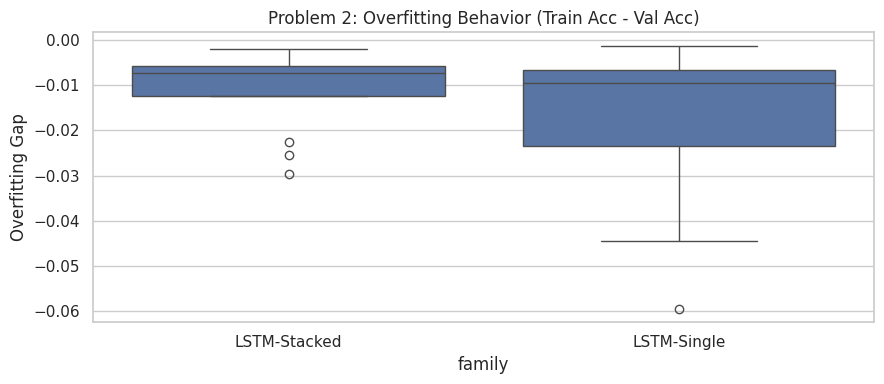

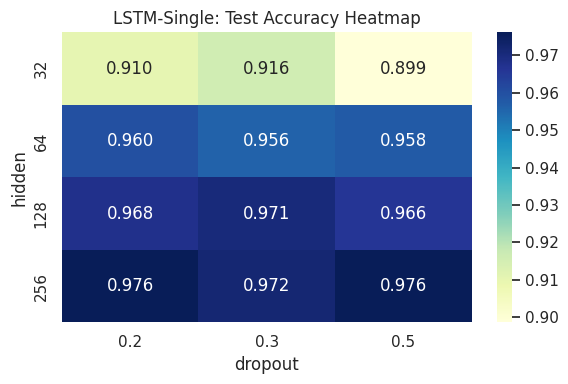

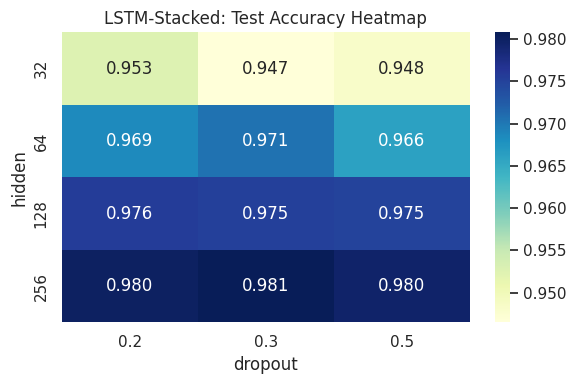

Epoch 01/6 | train_loss=0.4850 val_loss=0.1797 | train_acc=84.14% val_acc=94.92%
Epoch 02/6 | train_loss=0.1197 val_loss=0.0925 | train_acc=96.64% val_acc=97.28%
Epoch 03/6 | train_loss=0.0812 val_loss=0.0997 | train_acc=97.70% val_acc=97.08%
Epoch 04/6 | train_loss=0.0620 val_loss=0.0694 | train_acc=98.24% val_acc=98.20%
Epoch 05/6 | train_loss=0.0484 val_loss=0.0546 | train_acc=98.69% val_acc=98.47%
Epoch 06/6 | train_loss=0.0436 val_loss=0.0600 | train_acc=98.77% val_acc=98.35%


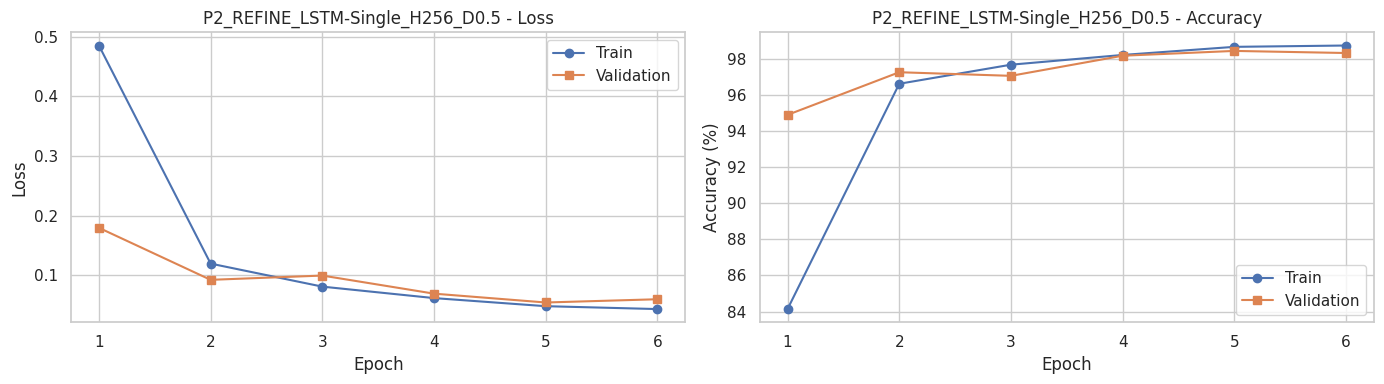

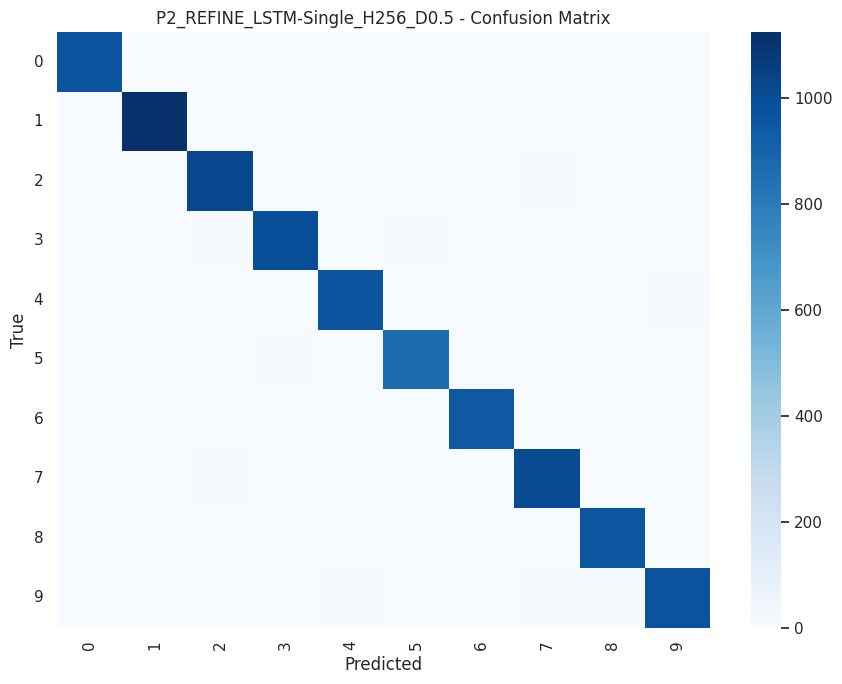

Epoch 01/6 | train_loss=0.3722 val_loss=0.1062 | train_acc=87.85% val_acc=96.82%
Epoch 02/6 | train_loss=0.0883 val_loss=0.0774 | train_acc=97.36% val_acc=97.65%
Epoch 03/6 | train_loss=0.0583 val_loss=0.0649 | train_acc=98.30% val_acc=98.12%
Epoch 04/6 | train_loss=0.0487 val_loss=0.0643 | train_acc=98.59% val_acc=98.08%
Epoch 05/6 | train_loss=0.0425 val_loss=0.0630 | train_acc=98.69% val_acc=98.10%
Epoch 06/6 | train_loss=0.0367 val_loss=0.0472 | train_acc=98.93% val_acc=98.67%


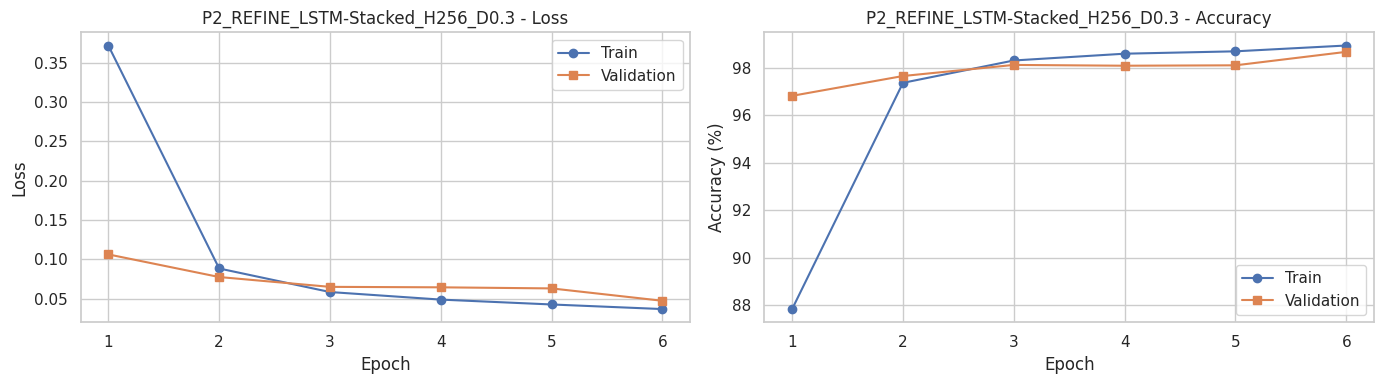

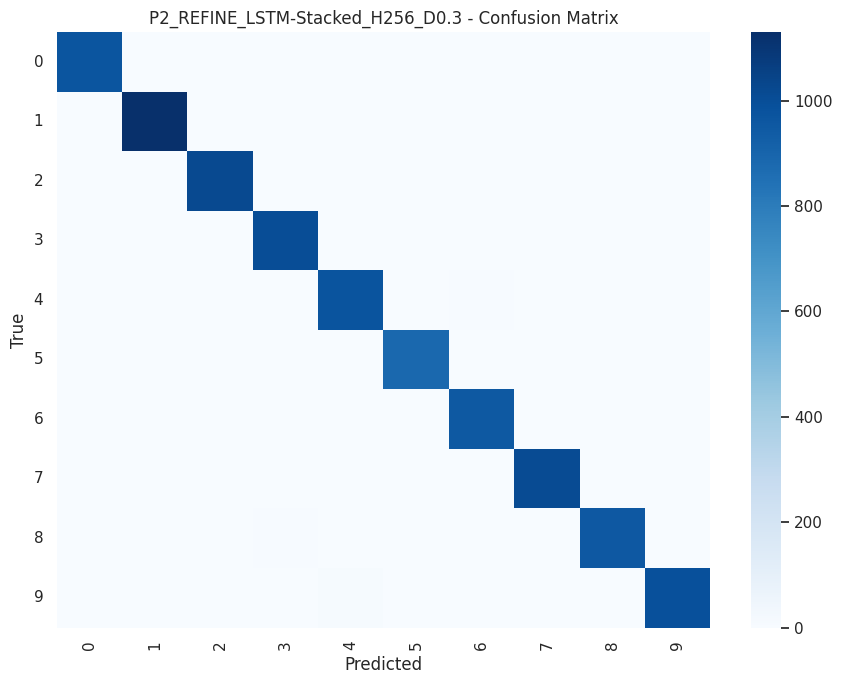

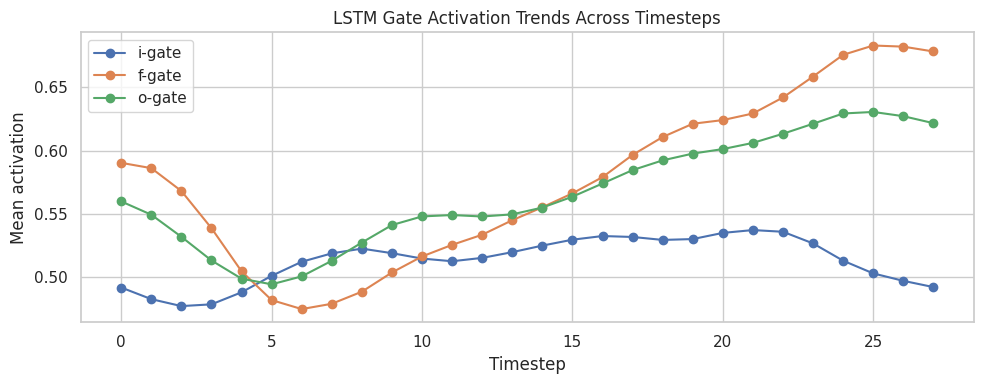

LSTM vs Vanilla RNN summary:
              Model  Test Accuracy  Train Time (s)  Params
0  Best Vanilla RNN         0.9572       28.187238  338954
1         Best LSTM         0.9808       27.677350  821770
Problem 2 completed.


In [5]:
class SingleLSTMClassifier(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_classes=10, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        feat = self.dropout(h_n[-1])
        return self.fc(feat)

    def extract_features(self, x):
        out, (h_n, c_n) = self.lstm(x)
        return h_n[-1]


class StackedLSTMClassifier(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=2, num_classes=10, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        return self.fc(h_n[-1])

    def extract_features(self, x):
        out, (h_n, c_n) = self.lstm(x)
        return h_n[-1]


class InstrumentedLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_ih = nn.Parameter(torch.randn(4 * hidden_size, input_size) * 0.02)
        self.W_hh = nn.Parameter(torch.randn(4 * hidden_size, hidden_size) * 0.02)
        self.b_ih = nn.Parameter(torch.zeros(4 * hidden_size))
        self.b_hh = nn.Parameter(torch.zeros(4 * hidden_size))

    def forward(self, x_t, h_prev, c_prev):
        gates = (
            F.linear(x_t, self.W_ih, self.b_ih)
            + F.linear(h_prev, self.W_hh, self.b_hh)
        )
        i_t, f_t, g_t, o_t = gates.chunk(4, dim=1)
        i_t = torch.sigmoid(i_t)
        f_t = torch.sigmoid(f_t)
        g_t = torch.tanh(g_t)
        o_t = torch.sigmoid(o_t)

        c_t = f_t * c_prev + i_t * g_t
        h_t = o_t * torch.tanh(c_t)
        gate_pack = {"i": i_t, "f": f_t, "o": o_t}
        return h_t, c_t, gate_pack


class InstrumentedLSTMClassifier(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_classes=10, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = InstrumentedLSTMCell(input_size=input_size, hidden_size=hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, return_gates=False):
        bsz, seq_len, _ = x.shape
        h = torch.zeros(bsz, self.hidden_size, device=x.device)
        c = torch.zeros(bsz, self.hidden_size, device=x.device)

        gate_logs = {"i": [], "f": [], "o": []}
        for t in range(seq_len):
            h, c, gates = self.cell(x[:, t, :], h, c)
            if return_gates:
                gate_logs["i"].append(gates["i"].detach().cpu())
                gate_logs["f"].append(gates["f"].detach().cpu())
                gate_logs["o"].append(gates["o"].detach().cpu())

        logits = self.fc(self.dropout(h))
        if return_gates:
            return logits, gate_logs
        return logits

    def extract_features(self, x):
        bsz, seq_len, _ = x.shape
        h = torch.zeros(bsz, self.hidden_size, device=x.device)
        c = torch.zeros(bsz, self.hidden_size, device=x.device)
        for t in range(seq_len):
            h, c, _ = self.cell(x[:, t, :], h, c)
        return h



def build_lstm_model(variant, hidden_size, dropout, num_classes):
    if variant == "LSTM-Single":
        return SingleLSTMClassifier(input_size=28, hidden_size=hidden_size, num_classes=num_classes, dropout=dropout)
    if variant == "LSTM-Stacked":
        return StackedLSTMClassifier(input_size=28, hidden_size=hidden_size, num_layers=2, num_classes=num_classes, dropout=dropout)
    raise ValueError(f"Unknown variant: {variant}")


lstm_rows = []
lstm_variants = ["LSTM-Single", "LSTM-Stacked"]
hidden_options = [32, 64, 128, 256]
dropout_options = [0.2, 0.3, 0.5]

for variant, hidden_size, dropout in tqdm(
    list(product(lstm_variants, hidden_options, dropout_options)),
    desc="Problem 2 Experiments",
):
    model = build_lstm_model(
        variant=variant,
        hidden_size=hidden_size,
        dropout=dropout,
        num_classes=DATASETS["MNIST"]["num_classes"],
    ).to(DEVICE)

    optimizer = optim.Adam(
        model.parameters(),
        lr=CONFIG.lr_default,
        weight_decay=CONFIG.weight_decay_default,
    )

    exp_name = f"P2_{variant}_H{hidden_size}_D{dropout}"
    row, hist, _ = run_experiment(
        model=model,
        experiment_name=exp_name,
        family=variant,
        problem="P2",
        dataset_name="MNIST",
        loaders=MNIST_LOADERS["sequence"]["row"],
        input_mode="sequence_row",
        optimizer=optimizer,
        criterion=criterion,
        epochs=CONFIG.epochs_screen,
        lr=CONFIG.lr_default,
        weight_decay=CONFIG.weight_decay_default,
        scheduler=None,
        grad_clip=CONFIG.grad_clip_default,
        early_stopping=None,
        capture_grads=False,
        meta={
            "cell_type": "lstm",
            "seq_len": 28,
            "input_size": 28,
            "hidden_size": hidden_size,
            "num_layers": 1 if variant == "LSTM-Single" else 2,
            "num_classes": DATASETS["MNIST"]["num_classes"],
            "bidirectional": False,
            "dropout": dropout,
        },
        verbose=False,
    )

    lstm_rows.append(row)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

lstm_df = pd.DataFrame(lstm_rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
print("Top Problem 2 configurations:")
print(lstm_df[["experiment", "family", "test_acc", "train_time_s", "params"]].head(10))

# Overfitting analysis: train/val gap by configuration
lstm_df["overfit_gap"] = lstm_df["train_acc_last"] - lstm_df["val_acc_last"]

plt.figure(figsize=(9, 4))
sns.boxplot(data=lstm_df, x="family", y="overfit_gap")
plt.title("Problem 2: Overfitting Behavior (Train Acc - Val Acc)")
plt.ylabel("Overfitting Gap")
plt.tight_layout()
plt.show()

# Accuracy heatmap for hidden size vs dropout
tmp = lstm_df.copy()
tmp["hidden"] = tmp["meta_hidden_size"].astype(int)
tmp["dropout"] = tmp["meta_dropout"].astype(float)
for variant in lstm_variants:
    pivot = (
        tmp[tmp["family"] == variant]
        .pivot_table(index="hidden", columns="dropout", values="test_acc", aggfunc="mean")
        .sort_index()
    )
    plt.figure(figsize=(6, 4))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
    plt.title(f"{variant}: Test Accuracy Heatmap")
    plt.tight_layout()
    plt.show()

# Refine best single and best stacked LSTM for richer curves and confusion matrices
lstm_refined_rows = []
for variant in lstm_variants:
    best_row = lstm_df[lstm_df["family"] == variant].iloc[0]
    hidden_size = int(best_row["meta_hidden_size"])
    dropout = float(best_row["meta_dropout"])

    model = build_lstm_model(
        variant=variant,
        hidden_size=hidden_size,
        dropout=dropout,
        num_classes=DATASETS["MNIST"]["num_classes"],
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=CONFIG.lr_default, weight_decay=CONFIG.weight_decay_default)
    exp_name = f"P2_REFINE_{variant}_H{hidden_size}_D{dropout}"

    row, hist, preds_eval = run_experiment(
        model=model,
        experiment_name=exp_name,
        family=f"{variant}-Refined",
        problem="P2",
        dataset_name="MNIST",
        loaders=MNIST_LOADERS["sequence"]["row"],
        input_mode="sequence_row",
        optimizer=optimizer,
        criterion=criterion,
        epochs=CONFIG.epochs_refine,
        lr=CONFIG.lr_default,
        weight_decay=CONFIG.weight_decay_default,
        scheduler=None,
        grad_clip=CONFIG.grad_clip_default,
        early_stopping=CONFIG.early_stopping_patience,
        capture_grads=False,
        meta={
            "cell_type": "lstm",
            "seq_len": 28,
            "input_size": 28,
            "hidden_size": hidden_size,
            "num_layers": 1 if variant == "LSTM-Single" else 2,
            "num_classes": DATASETS["MNIST"]["num_classes"],
            "bidirectional": False,
            "dropout": dropout,
        },
        verbose=True,
    )

    lstm_refined_rows.append(row)
    plot_training_curves(hist, title=exp_name)

    eval_preds = evaluate_model(model, MNIST_LOADERS["sequence"]["row"]["test"], criterion, return_preds=True)
    plot_confusion(
        eval_preds["targets"],
        eval_preds["preds"],
        DATASETS["MNIST"]["class_names"],
        title=f"{exp_name} - Confusion Matrix",
    )

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Gate activation visualization using instrumented LSTM
best_single = lstm_df[lstm_df["family"] == "LSTM-Single"].iloc[0]
inst_hidden = int(best_single["meta_hidden_size"])
inst_dropout = float(best_single["meta_dropout"])

inst_model = InstrumentedLSTMClassifier(
    input_size=28,
    hidden_size=inst_hidden,
    num_classes=DATASETS["MNIST"]["num_classes"],
    dropout=inst_dropout,
).to(DEVICE)

optimizer = optim.Adam(inst_model.parameters(), lr=CONFIG.lr_default, weight_decay=CONFIG.weight_decay_default)
_ = run_experiment(
    model=inst_model,
    experiment_name=f"P2_Instrumented_H{inst_hidden}_D{inst_dropout}",
    family="LSTM-Instrumented",
    problem="P2",
    dataset_name="MNIST",
    loaders=MNIST_LOADERS["sequence"]["row"],
    input_mode="sequence_row",
    optimizer=optimizer,
    criterion=criterion,
    epochs=max(2, CONFIG.epochs_refine),
    lr=CONFIG.lr_default,
    weight_decay=CONFIG.weight_decay_default,
    grad_clip=CONFIG.grad_clip_default,
    early_stopping=None,
    capture_grads=False,
    meta={
        "cell_type": "lstm",
        "seq_len": 28,
        "input_size": 28,
        "hidden_size": inst_hidden,
        "num_layers": 1,
        "num_classes": DATASETS["MNIST"]["num_classes"],
        "bidirectional": False,
        "dropout": inst_dropout,
    },
    verbose=False,
)

x_batch, y_batch = next(iter(MNIST_LOADERS["sequence"]["row"]["test"]))
x_batch = x_batch[:64].to(DEVICE)
inst_model.eval()
with torch.no_grad():
    logits, gates = inst_model(x_batch, return_gates=True)

# Mean gate activations over batch and hidden units by timestep
gate_curves = {}
for gname in ["i", "f", "o"]:
    vals = [g.mean().item() for g in gates[gname]]
    gate_curves[gname] = vals

plt.figure(figsize=(10, 4))
for gname, vals in gate_curves.items():
    plt.plot(vals, marker="o", label=f"{gname}-gate")
plt.title("LSTM Gate Activation Trends Across Timesteps")
plt.xlabel("Timestep")
plt.ylabel("Mean activation")
plt.legend()
plt.tight_layout()
plt.show()

# Compare best LSTM with best RNN from Problem 1
p1_best = p1_df.iloc[0]
p2_best = lstm_df.iloc[0]
compare_df = pd.DataFrame([
    {
        "Model": "Best Vanilla RNN",
        "Test Accuracy": p1_best["test_acc"],
        "Train Time (s)": p1_best["train_time_s"],
        "Params": p1_best["params"],
    },
    {
        "Model": "Best LSTM",
        "Test Accuracy": p2_best["test_acc"],
        "Train Time (s)": p2_best["train_time_s"],
        "Params": p2_best["params"],
    },
])
print("LSTM vs Vanilla RNN summary:")
print(compare_df)

print("Problem 2 completed.")

## 5) Problem 3: GRU

### Required implementations
- GRU with 1, 2, and 3 recurrent layers

### Required comparison with LSTM
- Accuracy
- Training time
- Parameter count
- Estimated FLOPs
- Estimated memory usage

### Discussion goal
Understand when GRU is preferable to LSTM.

Problem 3 GRU Depth:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 01/6 | train_loss=0.6080 val_loss=0.1940 | train_acc=80.20% val_acc=94.13%
Epoch 02/6 | train_loss=0.1205 val_loss=0.0961 | train_acc=96.45% val_acc=97.08%
Epoch 03/6 | train_loss=0.0773 val_loss=0.0761 | train_acc=97.72% val_acc=97.82%
Epoch 04/6 | train_loss=0.0594 val_loss=0.0739 | train_acc=98.19% val_acc=97.78%
Epoch 05/6 | train_loss=0.0473 val_loss=0.0608 | train_acc=98.56% val_acc=98.15%
Epoch 06/6 | train_loss=0.0395 val_loss=0.0473 | train_acc=98.78% val_acc=98.68%


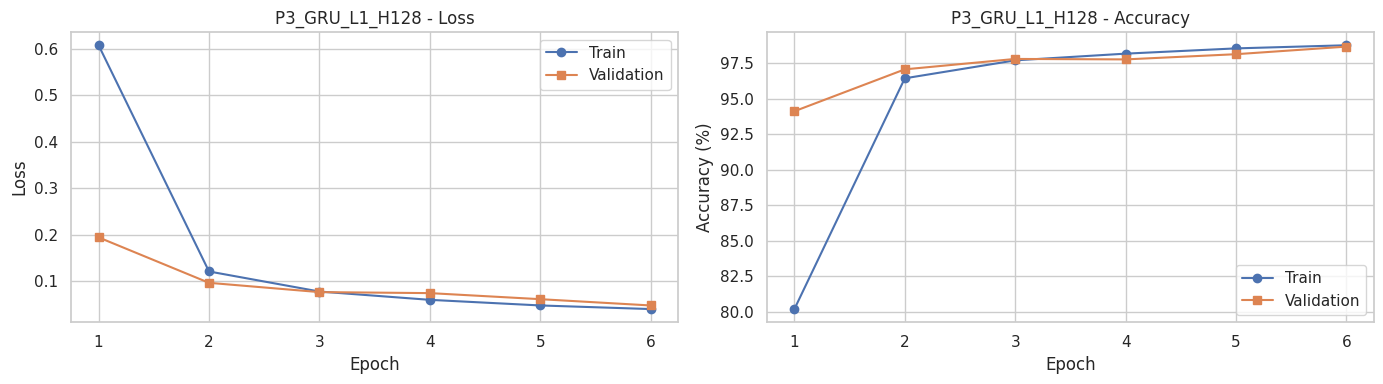

Epoch 01/6 | train_loss=0.4618 val_loss=0.1381 | train_acc=84.98% val_acc=95.92%
Epoch 02/6 | train_loss=0.0976 val_loss=0.0883 | train_acc=97.02% val_acc=97.20%
Epoch 03/6 | train_loss=0.0643 val_loss=0.0640 | train_acc=98.09% val_acc=98.03%
Epoch 04/6 | train_loss=0.0495 val_loss=0.0488 | train_acc=98.50% val_acc=98.62%
Epoch 05/6 | train_loss=0.0402 val_loss=0.0519 | train_acc=98.75% val_acc=98.42%
Epoch 06/6 | train_loss=0.0334 val_loss=0.0447 | train_acc=98.99% val_acc=98.70%


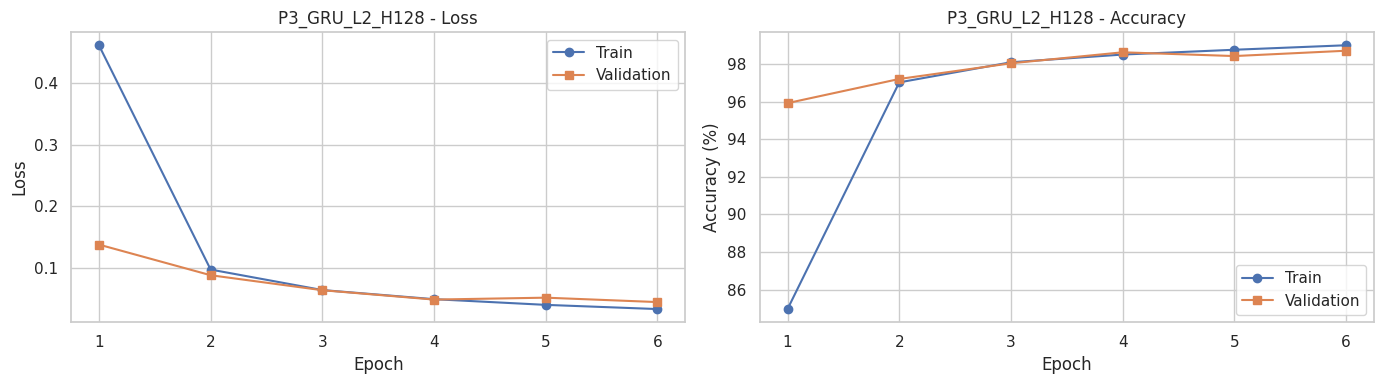

Epoch 01/6 | train_loss=0.4328 val_loss=0.1342 | train_acc=85.88% val_acc=95.95%
Epoch 02/6 | train_loss=0.0990 val_loss=0.0882 | train_acc=97.02% val_acc=97.15%
Epoch 03/6 | train_loss=0.0651 val_loss=0.0756 | train_acc=98.05% val_acc=97.77%
Epoch 04/6 | train_loss=0.0506 val_loss=0.0640 | train_acc=98.44% val_acc=98.15%
Epoch 05/6 | train_loss=0.0415 val_loss=0.0495 | train_acc=98.69% val_acc=98.42%
Epoch 06/6 | train_loss=0.0373 val_loss=0.0418 | train_acc=98.85% val_acc=98.73%


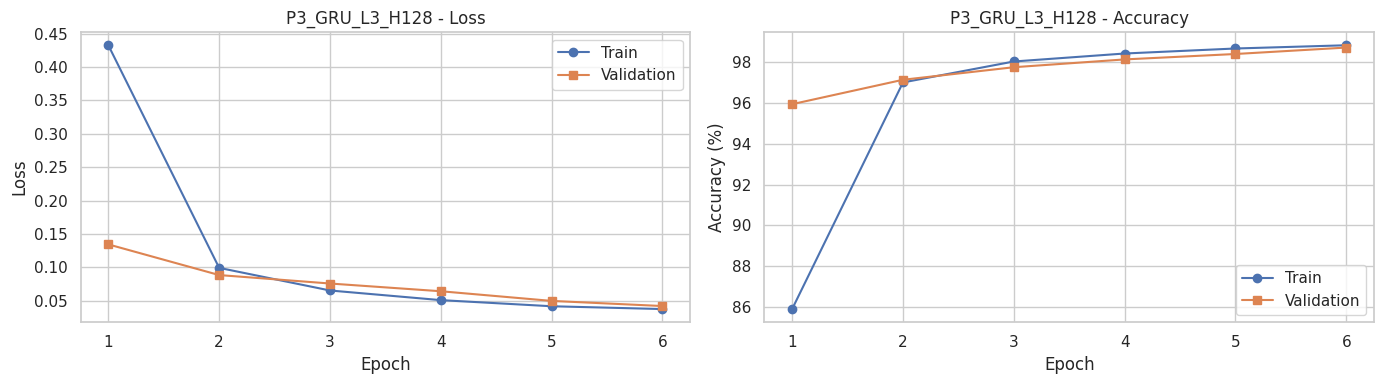

GRU results:
       experiment  test_acc  train_time_s  params  flops_est  memory_mb_est
0  P3_GRU_L3_H128    0.9891     83.526593  260106   10066432       6.242226
1  P3_GRU_L2_H128    0.9888     77.713914  161034    6711808       4.114296
2  P3_GRU_L1_H128    0.9850     76.414411   61962    3357184       1.986366
LSTM vs GRU (best settings):
       Model  Test Accuracy  Train Time (s)  Parameters  FLOPs (est)  \
0  Best LSTM         0.9808       27.677350      821770     32576512   
1   Best GRU         0.9891       83.526593      260106     10066432   

   Memory MB (est)  
0        10.134804  
1         6.242226  


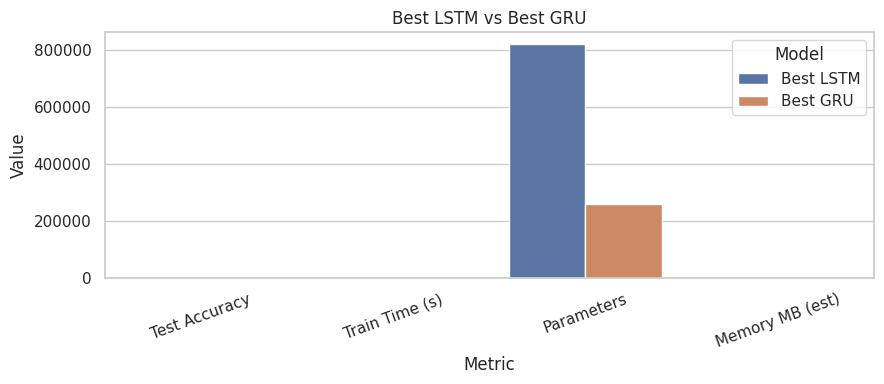

Discussion: GRU is often preferable when computational budget is constrained because it uses fewer gates than LSTM, typically reducing parameters, memory usage, and training/inference time while retaining competitive accuracy.
Problem 3 completed.


In [6]:
class GRUClassifier(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, h_n = self.gru(x)
        return self.fc(h_n[-1])

    def extract_features(self, x):
        out, h_n = self.gru(x)
        return h_n[-1]


gru_rows = []
for layers in tqdm([1, 2, 3], desc="Problem 3 GRU Depth"):
    model = GRUClassifier(
        input_size=28,
        hidden_size=128,
        num_layers=layers,
        num_classes=DATASETS["MNIST"]["num_classes"],
        dropout=0.3,
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=CONFIG.lr_default, weight_decay=CONFIG.weight_decay_default)
    exp_name = f"P3_GRU_L{layers}_H128"

    row, hist, _ = run_experiment(
        model=model,
        experiment_name=exp_name,
        family="GRU",
        problem="P3",
        dataset_name="MNIST",
        loaders=MNIST_LOADERS["sequence"]["row"],
        input_mode="sequence_row",
        optimizer=optimizer,
        criterion=criterion,
        epochs=CONFIG.epochs_refine,
        lr=CONFIG.lr_default,
        weight_decay=CONFIG.weight_decay_default,
        scheduler=None,
        grad_clip=CONFIG.grad_clip_default,
        early_stopping=CONFIG.early_stopping_patience,
        capture_grads=False,
        meta={
            "cell_type": "gru",
            "seq_len": 28,
            "input_size": 28,
            "hidden_size": 128,
            "num_layers": layers,
            "num_classes": DATASETS["MNIST"]["num_classes"],
            "bidirectional": False,
        },
        verbose=True,
    )

    gru_rows.append(row)
    plot_training_curves(hist, title=exp_name)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

gru_df = pd.DataFrame(gru_rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
print("GRU results:")
print(gru_df[["experiment", "test_acc", "train_time_s", "params", "flops_est", "memory_mb_est"]])

# Compare best GRU with best LSTM from Problem 2
best_gru = gru_df.iloc[0]
best_lstm = lstm_df.iloc[0]

comparison = pd.DataFrame([
    {
        "Model": "Best LSTM",
        "Test Accuracy": best_lstm["test_acc"],
        "Train Time (s)": best_lstm["train_time_s"],
        "Parameters": int(best_lstm["params"]),
        "FLOPs (est)": best_lstm["flops_est"],
        "Memory MB (est)": best_lstm["memory_mb_est"],
    },
    {
        "Model": "Best GRU",
        "Test Accuracy": best_gru["test_acc"],
        "Train Time (s)": best_gru["train_time_s"],
        "Parameters": int(best_gru["params"]),
        "FLOPs (est)": best_gru["flops_est"],
        "Memory MB (est)": best_gru["memory_mb_est"],
    },
])
print("LSTM vs GRU (best settings):")
print(comparison)

plt.figure(figsize=(9, 4))
plot_df = pd.melt(
    comparison,
    id_vars=["Model"],
    value_vars=["Test Accuracy", "Train Time (s)", "Parameters", "Memory MB (est)"],
    var_name="Metric",
    value_name="Value",
)
sns.barplot(data=plot_df, x="Metric", y="Value", hue="Model")
plt.title("Best LSTM vs Best GRU")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print(
    "Discussion: GRU is often preferable when computational budget is constrained "
    "because it uses fewer gates than LSTM, typically reducing parameters, memory usage, "
    "and training/inference time while retaining competitive accuracy."
)

print("Problem 3 completed.")

## 6) Problem 4: Bidirectional Models

### Implemented models
- BiLSTM with concatenation of forward/backward states
- BiLSTM with averaging of forward/backward states
- Bidirectional GRU

### Comparison targets
- Unidirectional LSTM and GRU baselines
- Impact of bidirectionality on sequence learning

Problem 4 Bidirectional:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 01/6 | train_loss=0.4401 val_loss=0.1379 | train_acc=85.83% val_acc=96.10%
Epoch 02/6 | train_loss=0.0949 val_loss=0.1033 | train_acc=97.14% val_acc=96.73%
Epoch 03/6 | train_loss=0.0660 val_loss=0.0668 | train_acc=98.01% val_acc=97.78%
Epoch 04/6 | train_loss=0.0496 val_loss=0.0636 | train_acc=98.45% val_acc=97.88%
Epoch 05/6 | train_loss=0.0398 val_loss=0.0586 | train_acc=98.79% val_acc=98.15%
Epoch 06/6 | train_loss=0.0356 val_loss=0.0647 | train_acc=98.91% val_acc=98.20%


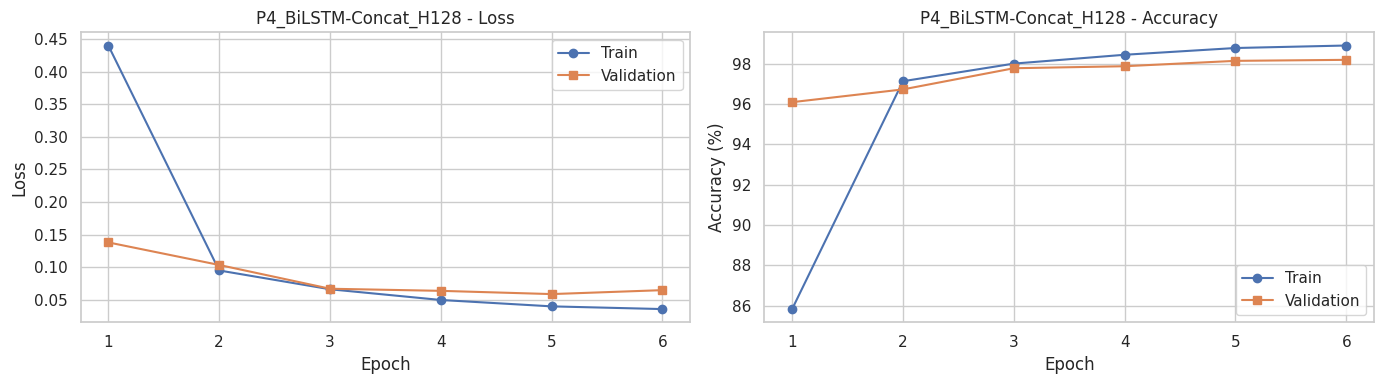

Epoch 01/6 | train_loss=0.4790 val_loss=0.1386 | train_acc=85.51% val_acc=95.78%
Epoch 02/6 | train_loss=0.0976 val_loss=0.0941 | train_acc=97.11% val_acc=97.20%
Epoch 03/6 | train_loss=0.0649 val_loss=0.0821 | train_acc=98.00% val_acc=97.63%
Epoch 04/6 | train_loss=0.0502 val_loss=0.0604 | train_acc=98.47% val_acc=97.95%
Epoch 05/6 | train_loss=0.0417 val_loss=0.0607 | train_acc=98.72% val_acc=98.08%
Epoch 06/6 | train_loss=0.0360 val_loss=0.0558 | train_acc=98.91% val_acc=98.27%


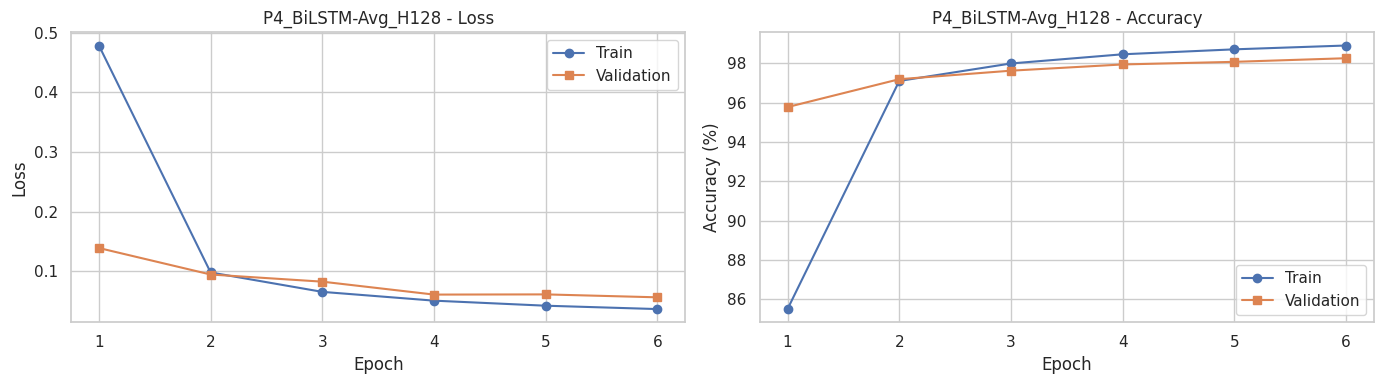

Epoch 01/6 | train_loss=0.4537 val_loss=0.1128 | train_acc=85.41% val_acc=97.00%
Epoch 02/6 | train_loss=0.0852 val_loss=0.0818 | train_acc=97.42% val_acc=97.65%
Epoch 03/6 | train_loss=0.0588 val_loss=0.0638 | train_acc=98.27% val_acc=98.15%
Epoch 04/6 | train_loss=0.0450 val_loss=0.0560 | train_acc=98.65% val_acc=98.33%
Epoch 05/6 | train_loss=0.0363 val_loss=0.0656 | train_acc=98.86% val_acc=98.23%
Epoch 06/6 | train_loss=0.0307 val_loss=0.0441 | train_acc=99.03% val_acc=98.63%


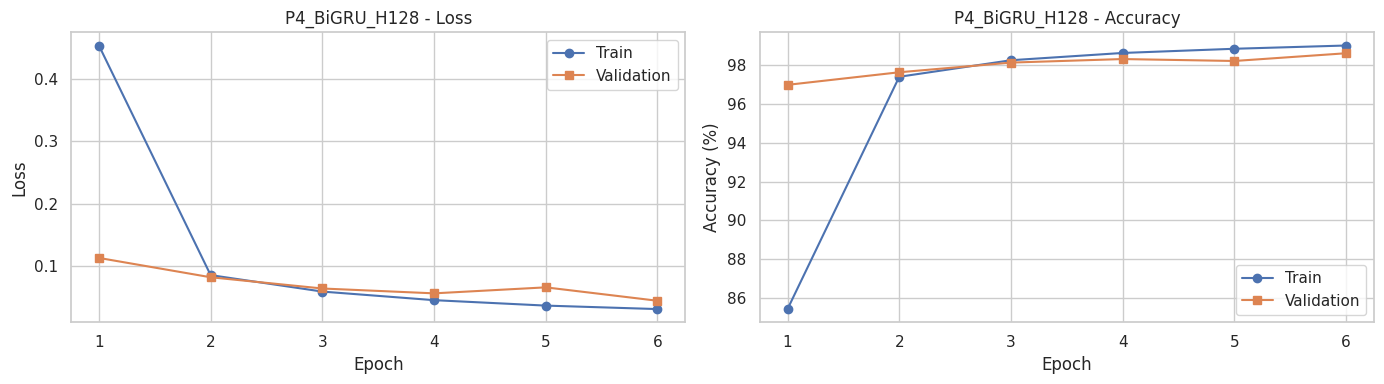

Bidirectional model results:
              experiment         family  test_acc  train_time_s  params
0          P4_BiGRU_H128          BiGRU    0.9878     78.890969  123914
1     P4_BiLSTM-Avg_H128     BiLSTM-Avg    0.9859     79.154992  163082
2  P4_BiLSTM-Concat_H128  BiLSTM-Concat    0.9815     78.827320  164362
                Model  Test Accuracy  Train Time (s)  Params
0       Best Uni-LSTM         0.9808       27.677350  821770
1        Best Uni-GRU         0.9891       83.526593  260106
2  Best Bidirectional         0.9878       78.890969  123914


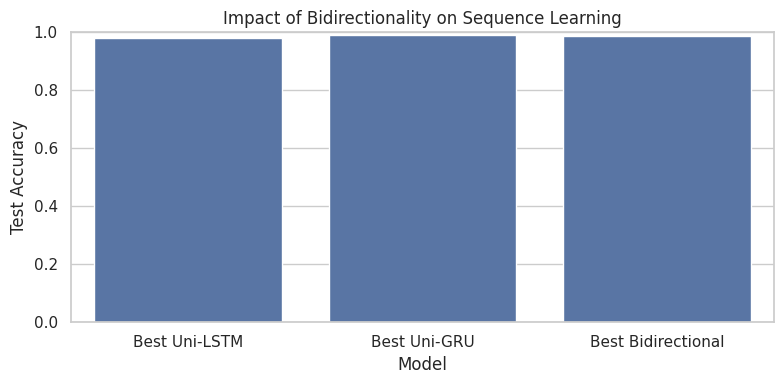

Problem 4 completed.


In [7]:
class BiLSTMConcatClassifier(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        feat = torch.cat([h_n[-2], h_n[-1]], dim=1)
        return self.fc(feat)

    def extract_features(self, x):
        out, (h_n, c_n) = self.lstm(x)
        return torch.cat([h_n[-2], h_n[-1]], dim=1)


class BiLSTMAverageClassifier(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        feat = 0.5 * (h_n[-2] + h_n[-1])
        return self.fc(feat)

    def extract_features(self, x):
        out, (h_n, c_n) = self.lstm(x)
        return 0.5 * (h_n[-2] + h_n[-1])


class BiGRUClassifier(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, h_n = self.gru(x)
        feat = torch.cat([h_n[-2], h_n[-1]], dim=1)
        return self.fc(feat)

    def extract_features(self, x):
        out, h_n = self.gru(x)
        return torch.cat([h_n[-2], h_n[-1]], dim=1)


bidir_models = {
    "BiLSTM-Concat": BiLSTMConcatClassifier,
    "BiLSTM-Avg": BiLSTMAverageClassifier,
    "BiGRU": BiGRUClassifier,
}

p4_rows = []
for name, cls in tqdm(bidir_models.items(), desc="Problem 4 Bidirectional"):
    model = cls(input_size=28, hidden_size=128, num_layers=1, num_classes=10, dropout=0.3).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=CONFIG.lr_default, weight_decay=CONFIG.weight_decay_default)

    cell_type = "gru" if "GRU" in name else "lstm"
    exp_name = f"P4_{name}_H128"

    row, hist, _ = run_experiment(
        model=model,
        experiment_name=exp_name,
        family=name,
        problem="P4",
        dataset_name="MNIST",
        loaders=MNIST_LOADERS["sequence"]["row"],
        input_mode="sequence_row",
        optimizer=optimizer,
        criterion=criterion,
        epochs=CONFIG.epochs_refine,
        lr=CONFIG.lr_default,
        weight_decay=CONFIG.weight_decay_default,
        scheduler=None,
        grad_clip=CONFIG.grad_clip_default,
        early_stopping=CONFIG.early_stopping_patience,
        capture_grads=False,
        meta={
            "cell_type": cell_type,
            "seq_len": 28,
            "input_size": 28,
            "hidden_size": 128,
            "num_layers": 1,
            "num_classes": 10,
            "bidirectional": True,
        },
        verbose=True,
    )

    p4_rows.append(row)
    plot_training_curves(hist, title=exp_name)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

p4_df = pd.DataFrame(p4_rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
print("Bidirectional model results:")
print(p4_df[["experiment", "family", "test_acc", "train_time_s", "params"]])

# Compare with best unidirectional LSTM and GRU
uni_best_lstm = lstm_df.iloc[0]
uni_best_gru = gru_df.iloc[0]
bi_best = p4_df.iloc[0]

seq_compare = pd.DataFrame([
    {
        "Model": "Best Uni-LSTM",
        "Test Accuracy": uni_best_lstm["test_acc"],
        "Train Time (s)": uni_best_lstm["train_time_s"],
        "Params": uni_best_lstm["params"],
    },
    {
        "Model": "Best Uni-GRU",
        "Test Accuracy": uni_best_gru["test_acc"],
        "Train Time (s)": uni_best_gru["train_time_s"],
        "Params": uni_best_gru["params"],
    },
    {
        "Model": "Best Bidirectional",
        "Test Accuracy": bi_best["test_acc"],
        "Train Time (s)": bi_best["train_time_s"],
        "Params": bi_best["params"],
    },
])
print(seq_compare)

plt.figure(figsize=(8, 4))
sns.barplot(data=seq_compare, x="Model", y="Test Accuracy")
plt.title("Impact of Bidirectionality on Sequence Learning")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Problem 4 completed.")

## 7) Problem 5: CNN + LSTM Hybrid Models

### Implemented models
1. CNN feature extractor + LSTM
2. TimeDistributed CNN + LSTM

Additional baseline:
- Pure CNN classifier

### Required analysis
- Compare CNN vs RNN vs Hybrid performance
- Visualize CNN feature maps
- Visualize temporal hidden states

Problem 5 CNN/Hybrid:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 01/6 | train_loss=0.1519 val_loss=0.0439 | train_acc=95.27% val_acc=98.50%
Epoch 02/6 | train_loss=0.0444 val_loss=0.0352 | train_acc=98.62% val_acc=98.93%
Epoch 03/6 | train_loss=0.0311 val_loss=0.0373 | train_acc=99.03% val_acc=99.07%
Epoch 04/6 | train_loss=0.0250 val_loss=0.0335 | train_acc=99.24% val_acc=99.15%
Epoch 05/6 | train_loss=0.0223 val_loss=0.0278 | train_acc=99.30% val_acc=99.27%
Epoch 06/6 | train_loss=0.0187 val_loss=0.0266 | train_acc=99.38% val_acc=99.15%


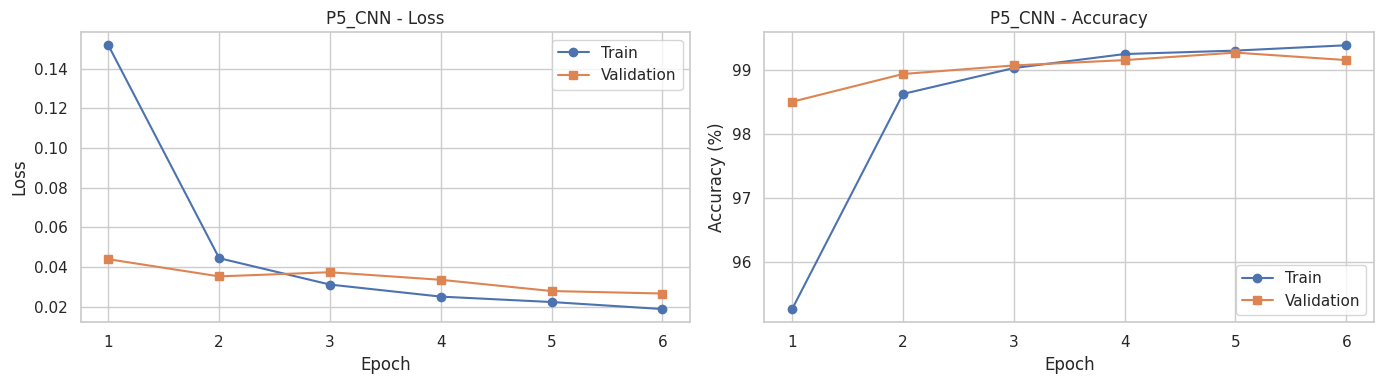

Epoch 01/6 | train_loss=0.2826 val_loss=0.0819 | train_acc=91.89% val_acc=97.65%
Epoch 02/6 | train_loss=0.0553 val_loss=0.0439 | train_acc=98.36% val_acc=98.65%
Epoch 03/6 | train_loss=0.0376 val_loss=0.0393 | train_acc=98.86% val_acc=98.80%
Epoch 04/6 | train_loss=0.0259 val_loss=0.0360 | train_acc=99.20% val_acc=98.87%
Epoch 05/6 | train_loss=0.0225 val_loss=0.0317 | train_acc=99.36% val_acc=99.02%
Epoch 06/6 | train_loss=0.0175 val_loss=0.0368 | train_acc=99.48% val_acc=98.98%


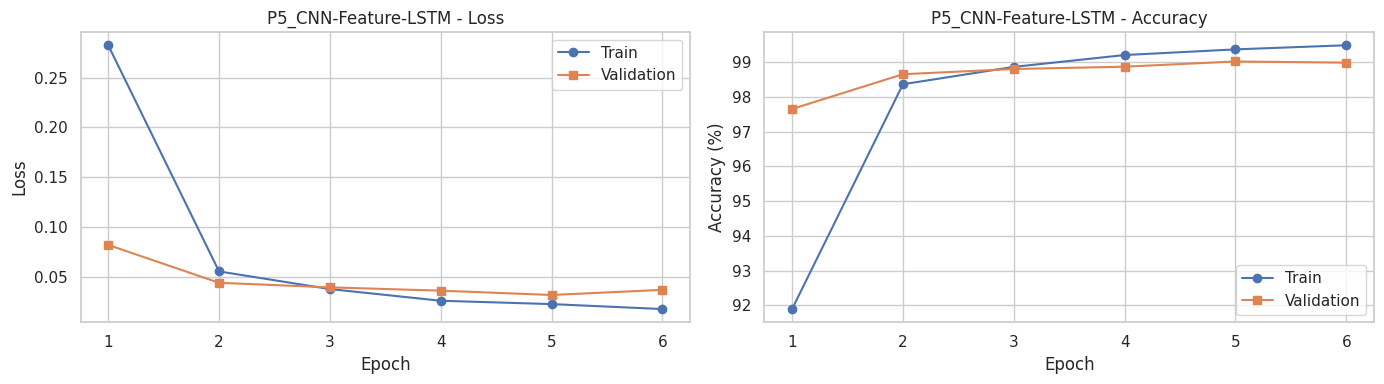

Epoch 01/6 | train_loss=0.6434 val_loss=0.2080 | train_acc=79.40% val_acc=93.50%
Epoch 02/6 | train_loss=0.1561 val_loss=0.1221 | train_acc=95.26% val_acc=96.43%
Epoch 03/6 | train_loss=0.1006 val_loss=0.0992 | train_acc=96.96% val_acc=96.87%
Epoch 04/6 | train_loss=0.0729 val_loss=0.0716 | train_acc=97.77% val_acc=97.75%
Epoch 05/6 | train_loss=0.0608 val_loss=0.0781 | train_acc=98.12% val_acc=97.48%
Epoch 06/6 | train_loss=0.0519 val_loss=0.0526 | train_acc=98.37% val_acc=98.27%


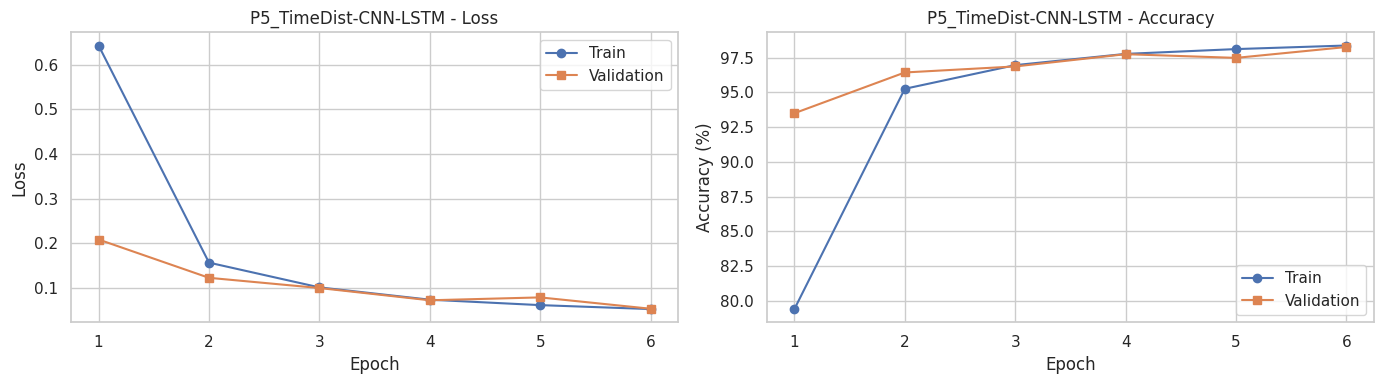

Problem 5 results:
             experiment             family  test_acc  train_time_s  params
0                P5_CNN                CNN    0.9930     85.476971  870826
1   P5_CNN-Feature-LSTM   CNN-Feature-LSTM    0.9912     82.412809  316042
2  P5_TimeDist-CNN-LSTM  TimeDist-CNN-LSTM    0.9843     93.392755  138186
              Model  Test Accuracy  Train Time (s)  Params
0  Best Vanilla RNN         0.9572       28.187238  338954
1          Pure CNN         0.9930       85.476971  870826
2       Best Hybrid         0.9930       85.476971  870826


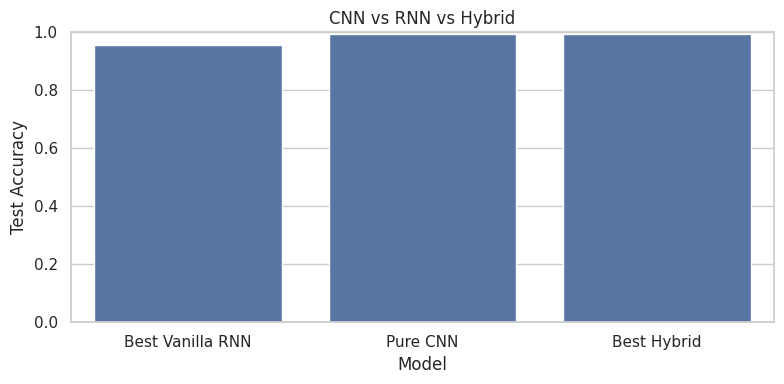

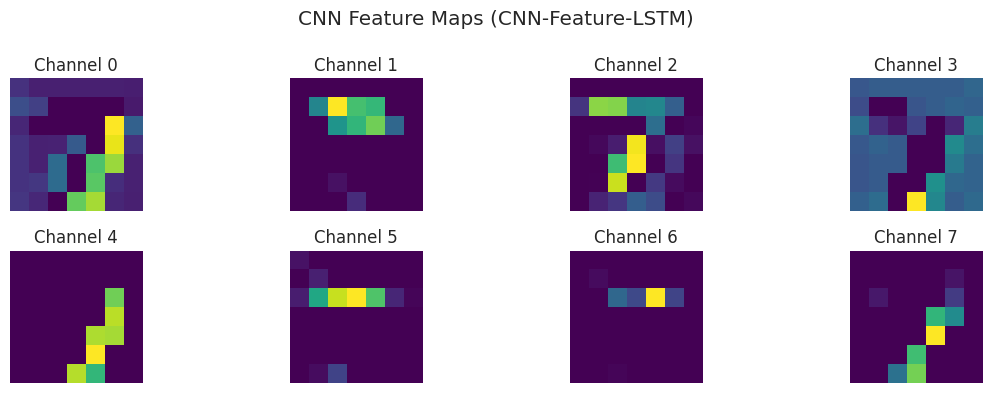

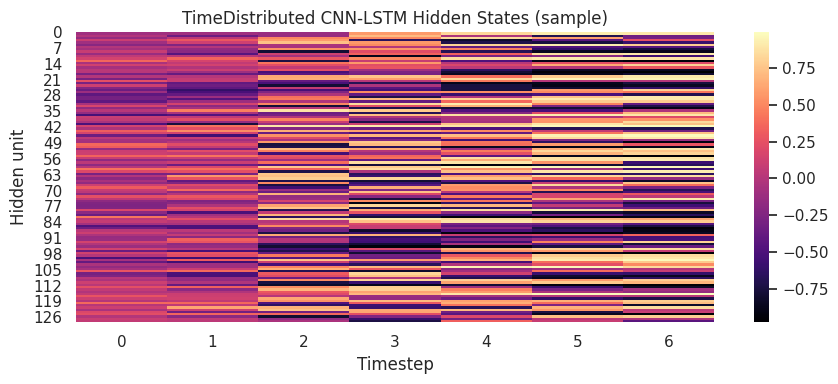

Problem 5 completed.


In [8]:
class CNNBaseline(nn.Module):
    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        fmap = self.features(x)
        return self.classifier(fmap)

    def extract_features(self, x):
        fmap = self.features(x)
        return fmap.flatten(1)

    def extract_feature_maps(self, x):
        return self.features(x)


class CNNFeatureLSTM(nn.Module):
    def __init__(self, num_classes=10, hidden_size=128, num_layers=1, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # After conv: [B, 64, 7, 7] => sequence length 7, feature size 64*7
        self.lstm = nn.LSTM(
            input_size=64 * 7,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, return_hidden_sequence=False):
        fmap = self.conv(x)  # [B, 64, 7, 7]
        seq = fmap.permute(0, 3, 1, 2).contiguous().view(x.size(0), 7, 64 * 7)
        out, (h_n, c_n) = self.lstm(seq)
        logits = self.fc(h_n[-1])
        if return_hidden_sequence:
            return logits, out
        return logits

    def extract_features(self, x):
        fmap = self.conv(x)
        seq = fmap.permute(0, 3, 1, 2).contiguous().view(x.size(0), 7, 64 * 7)
        out, (h_n, c_n) = self.lstm(seq)
        return h_n[-1]

    def extract_feature_maps(self, x):
        return self.conv(x)


class TimeDistributedCNNLSTM(nn.Module):
    def __init__(self, num_classes=10, hidden_size=128, num_slices=7, dropout=0.3):
        super().__init__()
        self.num_slices = num_slices
        self.slice_encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 4)),
        )
        self.lstm = nn.LSTM(input_size=32 * 4, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, return_hidden_sequence=False):
        # x: [B, 1, 28, 28]
        bsz, c, h, w = x.shape
        assert h % self.num_slices == 0, "Image height must be divisible by num_slices"
        slice_h = h // self.num_slices

        x_seq = x.view(bsz, self.num_slices, c, slice_h, w)
        feats = []
        for t in range(self.num_slices):
            ft = self.slice_encoder(x_seq[:, t])
            feats.append(ft.flatten(1))
        seq = torch.stack(feats, dim=1)

        out, (h_n, c_n) = self.lstm(seq)
        logits = self.fc(self.dropout(h_n[-1]))
        if return_hidden_sequence:
            return logits, out
        return logits

    def extract_features(self, x):
        bsz, c, h, w = x.shape
        slice_h = h // self.num_slices
        x_seq = x.view(bsz, self.num_slices, c, slice_h, w)

        feats = []
        for t in range(self.num_slices):
            ft = self.slice_encoder(x_seq[:, t])
            feats.append(ft.flatten(1))
        seq = torch.stack(feats, dim=1)

        out, (h_n, c_n) = self.lstm(seq)
        return h_n[-1]


hybrid_builders = {
    "CNN": lambda nc: CNNBaseline(num_classes=nc, dropout=0.3),
    "CNN-Feature-LSTM": lambda nc: CNNFeatureLSTM(num_classes=nc, hidden_size=128, num_layers=1, dropout=0.3),
    "TimeDist-CNN-LSTM": lambda nc: TimeDistributedCNNLSTM(num_classes=nc, hidden_size=128, num_slices=7, dropout=0.3),
}

p5_rows = []
for family, builder in tqdm(hybrid_builders.items(), desc="Problem 5 CNN/Hybrid"):
    model = builder(DATASETS["MNIST"]["num_classes"]).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=CONFIG.lr_default, weight_decay=CONFIG.weight_decay_default)
    exp_name = f"P5_{family}"

    row, hist, _ = run_experiment(
        model=model,
        experiment_name=exp_name,
        family=family,
        problem="P5",
        dataset_name="MNIST",
        loaders=MNIST_LOADERS["image"],
        input_mode="image",
        optimizer=optimizer,
        criterion=criterion,
        epochs=CONFIG.epochs_refine,
        lr=CONFIG.lr_default,
        weight_decay=CONFIG.weight_decay_default,
        scheduler=None,
        grad_clip=CONFIG.grad_clip_default,
        early_stopping=CONFIG.early_stopping_patience,
        capture_grads=False,
        meta={
            "cell_type": "cnn" if family == "CNN" else "lstm",
            "seq_len": 7,
            "input_size": 64 * 7 if family == "CNN-Feature-LSTM" else 32 * 4,
            "hidden_size": 128,
            "num_layers": 1,
            "num_classes": 10,
            "bidirectional": False,
            "cnn_flops": 8e6 if family == "CNN" else 1.2e7,
        },
        verbose=True,
    )

    p5_rows.append(row)
    plot_training_curves(hist, title=exp_name)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

p5_df = pd.DataFrame(p5_rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
print("Problem 5 results:")
print(p5_df[["experiment", "family", "test_acc", "train_time_s", "params"]])

# Compare pure CNN vs best RNN family vs hybrid best
best_rnn = p1_df.iloc[0]
best_hybrid = p5_df.iloc[0]
best_cnn = p5_df[p5_df["family"] == "CNN"].iloc[0]

cnn_rnn_hybrid_cmp = pd.DataFrame([
    {
        "Model": "Best Vanilla RNN",
        "Test Accuracy": best_rnn["test_acc"],
        "Train Time (s)": best_rnn["train_time_s"],
        "Params": best_rnn["params"],
    },
    {
        "Model": "Pure CNN",
        "Test Accuracy": best_cnn["test_acc"],
        "Train Time (s)": best_cnn["train_time_s"],
        "Params": best_cnn["params"],
    },
    {
        "Model": "Best Hybrid",
        "Test Accuracy": best_hybrid["test_acc"],
        "Train Time (s)": best_hybrid["train_time_s"],
        "Params": best_hybrid["params"],
    },
])
print(cnn_rnn_hybrid_cmp)

plt.figure(figsize=(8, 4))
sns.barplot(data=cnn_rnn_hybrid_cmp, x="Model", y="Test Accuracy")
plt.ylim(0, 1)
plt.title("CNN vs RNN vs Hybrid")
plt.tight_layout()
plt.show()

# Feature map visualization using the best CNN-Feature-LSTM model
best_cnn_lstm_row = p5_df[p5_df["family"] == "CNN-Feature-LSTM"].iloc[0] if (p5_df["family"] == "CNN-Feature-LSTM").any() else None
if best_cnn_lstm_row is not None:
    viz_model = CNNFeatureLSTM(num_classes=10, hidden_size=128, num_layers=1, dropout=0.3).to(DEVICE)
    opt = optim.Adam(viz_model.parameters(), lr=CONFIG.lr_default)
    # quick short fit so feature maps are meaningful for this runtime
    _ = run_experiment(
        model=viz_model,
        experiment_name="P5_VIZ_CNNFeatureLSTM",
        family="CNN-Feature-LSTM-Viz",
        problem="P5",
        dataset_name="MNIST",
        loaders=MNIST_LOADERS["image"],
        input_mode="image",
        optimizer=opt,
        criterion=criterion,
        epochs=max(1, CONFIG.epochs_screen),
        lr=CONFIG.lr_default,
        grad_clip=CONFIG.grad_clip_default,
        meta={"cell_type": "lstm", "seq_len": 7, "input_size": 64 * 7, "hidden_size": 128, "num_layers": 1, "num_classes": 10},
        verbose=False,
    )

    x_batch, y_batch = next(iter(MNIST_LOADERS["image"]["test"]))
    x1 = x_batch[:1].to(DEVICE)
    fmap = viz_model.extract_feature_maps(x1).detach().cpu()[0]

    plt.figure(figsize=(12, 4))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(fmap[i], cmap="viridis")
        plt.title(f"Channel {i}")
        plt.axis("off")
    plt.suptitle("CNN Feature Maps (CNN-Feature-LSTM)")
    plt.tight_layout()
    plt.show()

    del viz_model
    gc.collect()

# Hidden-state visualization for TimeDistributed CNN-LSTM
td_model = TimeDistributedCNNLSTM(num_classes=10, hidden_size=128, num_slices=7, dropout=0.3).to(DEVICE)
opt = optim.Adam(td_model.parameters(), lr=CONFIG.lr_default)
_ = run_experiment(
    model=td_model,
    experiment_name="P5_VIZ_TimeDistCNNLSTM",
    family="TimeDist-CNN-LSTM-Viz",
    problem="P5",
    dataset_name="MNIST",
    loaders=MNIST_LOADERS["image"],
    input_mode="image",
    optimizer=opt,
    criterion=criterion,
    epochs=max(1, CONFIG.epochs_screen),
    lr=CONFIG.lr_default,
    grad_clip=CONFIG.grad_clip_default,
    meta={"cell_type": "lstm", "seq_len": 7, "input_size": 32 * 4, "hidden_size": 128, "num_layers": 1, "num_classes": 10},
    verbose=False,
)

x_batch, _ = next(iter(MNIST_LOADERS["image"]["test"]))
x1 = x_batch[:1].to(DEVICE)
td_model.eval()
with torch.no_grad():
    logits, hidden_seq = td_model(x1, return_hidden_sequence=True)

hidden_seq_np = hidden_seq[0].detach().cpu().numpy().T  # [hidden, time]
plt.figure(figsize=(9, 4))
sns.heatmap(hidden_seq_np, cmap="magma", cbar=True)
plt.title("TimeDistributed CNN-LSTM Hidden States (sample)")
plt.xlabel("Timestep")
plt.ylabel("Hidden unit")
plt.tight_layout()
plt.show()

print("Problem 5 completed.")

## 8) Problem 6: Hyperparameter Tuning

This section performs controlled experiments over:

- Learning rates: 0.1, 0.01, 0.001
- Batch sizes: 32, 64, 128
- Optimizers: SGD, Adam, RMSprop

Regularization and stabilization techniques used in each run:

- Dropout
- L2 regularization (weight decay)
- Early stopping
- Gradient clipping
- Learning-rate scheduler

Problem 6 Tuning:   0%|          | 0/27 [00:00<?, ?it/s]

Top hyperparameter settings:
                      experiment optimizer     lr  batch_size  test_acc  \
0   P6_TUNE_RMSprop_LR0.001_BS32   RMSprop  0.001          32   0.97125   
1      P6_TUNE_Adam_LR0.001_BS32      Adam  0.001          32   0.96700   
2       P6_TUNE_Adam_LR0.01_BS64      Adam  0.010          64   0.96475   
3    P6_TUNE_RMSprop_LR0.01_BS64   RMSprop  0.010          64   0.95900   
4      P6_TUNE_Adam_LR0.01_BS128      Adam  0.010         128   0.95875   
5       P6_TUNE_Adam_LR0.01_BS32      Adam  0.010          32   0.95825   
6      P6_TUNE_Adam_LR0.001_BS64      Adam  0.001          64   0.95725   
7   P6_TUNE_RMSprop_LR0.001_BS64   RMSprop  0.001          64   0.95675   
8    P6_TUNE_RMSprop_LR0.01_BS32   RMSprop  0.010          32   0.95500   
9  P6_TUNE_RMSprop_LR0.001_BS128   RMSprop  0.001         128   0.95425   

   train_time_s  
0     14.157733  
1     14.038956  
2     11.551275  
3     11.405612  
4     10.372849  
5     14.104905  
6     11.929453  
7

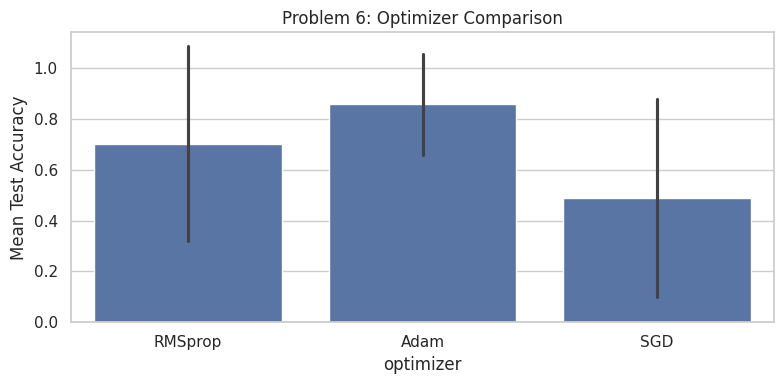

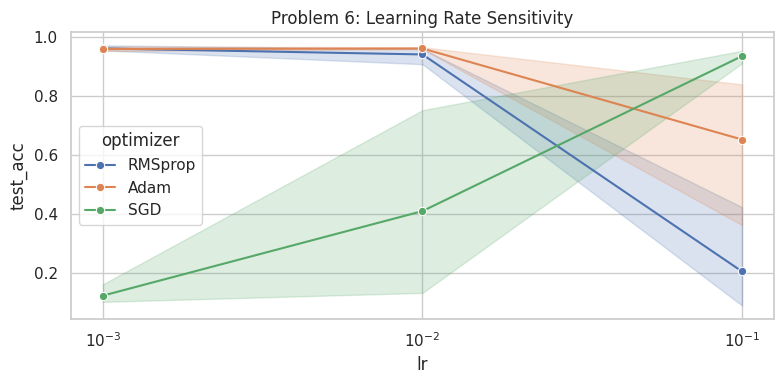

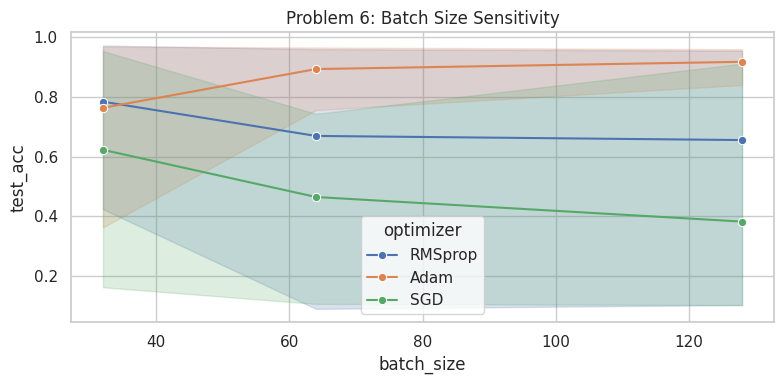

Best tuning configuration:
experiment      P6_TUNE_RMSprop_LR0.001_BS32
optimizer                            RMSprop
lr                                     0.001
batch_size                                32
test_acc                             0.97125
train_time_s                       14.157733
Name: 0, dtype: object
Problem 6 completed.


In [9]:
def build_tuning_model(num_classes=10, dropout=0.3):
    return StackedLSTMClassifier(
        input_size=28,
        hidden_size=128,
        num_layers=2,
        num_classes=num_classes,
        dropout=dropout,
    )


# Smaller split for full-factorial tuning to keep runtime practical.
tune_train = subset_dataset(DATASETS["MNIST"]["splits"]["train"], 4000 if CONFIG.fast_mode else 12000, seed=2026)
tune_val = subset_dataset(DATASETS["MNIST"]["splits"]["val"], 1000 if CONFIG.fast_mode else 2000, seed=2026)
tune_test = subset_dataset(DATASETS["MNIST"]["splits"]["test"], 2000 if CONFIG.fast_mode else 4000, seed=2026)
TUNE_SPLITS = {"train": tune_train, "val": tune_val, "test": tune_test}


def tuning_loaders(batch_size):
    return build_all_loaders_for_dataset(TUNE_SPLITS, batch_size)["sequence"]["row"]


lr_options = [0.1, 0.01, 0.001]
batch_options = [32, 64, 128]
opt_options = {
    "SGD": optim.SGD,
    "Adam": optim.Adam,
    "RMSprop": optim.RMSprop,
}

tuning_rows = []
for lr, bsz, opt_name in tqdm(list(product(lr_options, batch_options, opt_options.keys())), desc="Problem 6 Tuning"):
    loaders = tuning_loaders(bsz)
    model = build_tuning_model(num_classes=10, dropout=0.3).to(DEVICE)

    opt_cls = opt_options[opt_name]
    if opt_name == "SGD":
        optimizer = opt_cls(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    else:
        optimizer = opt_cls(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.7)

    exp_name = f"P6_TUNE_{opt_name}_LR{lr}_BS{bsz}"
    row, hist, _ = run_experiment(
        model=model,
        experiment_name=exp_name,
        family="Tuning-LSTM",
        problem="P6",
        dataset_name="MNIST",
        loaders=loaders,
        input_mode="sequence_row",
        optimizer=optimizer,
        criterion=criterion,
        epochs=max(1, CONFIG.epochs_tuning),
        lr=lr,
        weight_decay=1e-4,
        scheduler=scheduler,
        grad_clip=CONFIG.grad_clip_default,
        early_stopping=CONFIG.early_stopping_patience,
        capture_grads=False,
        meta={
            "cell_type": "lstm",
            "seq_len": 28,
            "input_size": 28,
            "hidden_size": 128,
            "num_layers": 2,
            "num_classes": 10,
            "bidirectional": False,
            "optimizer": opt_name,
            "batch_size": bsz,
            "dropout": 0.3,
            "scheduler": "StepLR(gamma=0.7)",
            "grad_clip": CONFIG.grad_clip_default,
        },
        verbose=False,
    )

    tuning_rows.append(row)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

tuning_df = pd.DataFrame(tuning_rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
tuning_df["optimizer"] = tuning_df["meta_optimizer"]
tuning_df["batch_size"] = tuning_df["meta_batch_size"].astype(int)

print("Top hyperparameter settings:")
print(tuning_df[["experiment", "optimizer", "lr", "batch_size", "test_acc", "train_time_s"]].head(10))

plt.figure(figsize=(8, 4))
sns.barplot(data=tuning_df, x="optimizer", y="test_acc", estimator=np.mean, errorbar="sd")
plt.title("Problem 6: Optimizer Comparison")
plt.ylabel("Mean Test Accuracy")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.lineplot(data=tuning_df, x="lr", y="test_acc", hue="optimizer", marker="o")
plt.xscale("log")
plt.title("Problem 6: Learning Rate Sensitivity")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.lineplot(data=tuning_df, x="batch_size", y="test_acc", hue="optimizer", marker="o")
plt.title("Problem 6: Batch Size Sensitivity")
plt.tight_layout()
plt.show()

best_tune = tuning_df.iloc[0]
print("Best tuning configuration:")
print(best_tune[["experiment", "optimizer", "lr", "batch_size", "test_acc", "train_time_s"]])

print("Problem 6 completed.")

## 9) Problem 7: Final Comparison and Analysis

This section aggregates all experiments and provides the required final analysis:

- Test accuracy
- Parameter count
- Training time
- Inference time
- Memory usage
- Convergence speed

Required visualizations:

- Training curves
- Confusion matrices
- Bar charts
- t-SNE feature projection
- Misclassified samples

EMNIST Benchmarks:   0%|          | 0/6 [00:00<?, ?it/s]

EMNIST benchmark summary:
            family  test_acc  train_time_s  params  inference_ms_sample
0       EMNIST-CNN  0.873617     50.824557  880335             0.032385
1  EMNIST-CNN-LSTM  0.858617     49.973979  320815             0.038963
2       EMNIST-GRU  0.837074     51.159709  165807             0.029678
3      EMNIST-LSTM  0.835106     51.517153  219055             0.033224
4    EMNIST-BiLSTM  0.831330     51.872826  173871             0.031843
5       EMNIST-RNN  0.701809     49.295782   59311             0.017077
Total experiment runs logged: 111

Final comparison table (best run per family):
   dataset                family  test_acc  params  train_time_s  \
1   EMNIST            EMNIST-CNN  0.873617  880335     50.824557   
2   EMNIST       EMNIST-CNN-LSTM  0.858617  320815     49.973979   
3   EMNIST            EMNIST-GRU  0.837074  165807     51.159709   
4   EMNIST           EMNIST-LSTM  0.835106  219055     51.517153   
0   EMNIST         EMNIST-BiLSTM  0.831330  17387

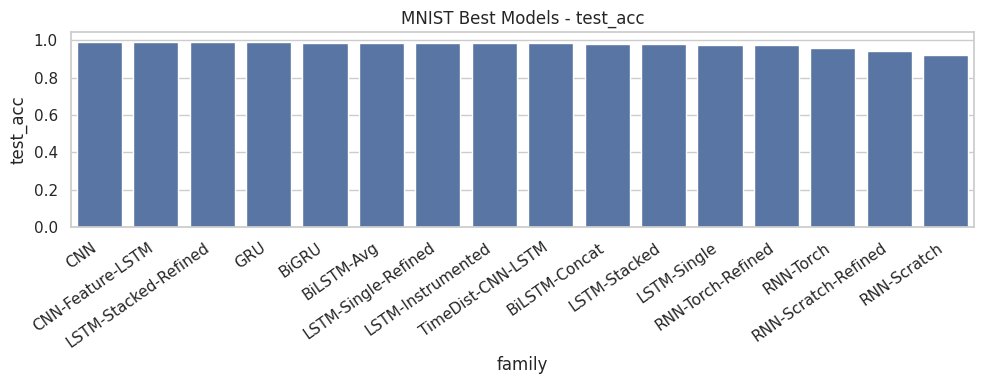

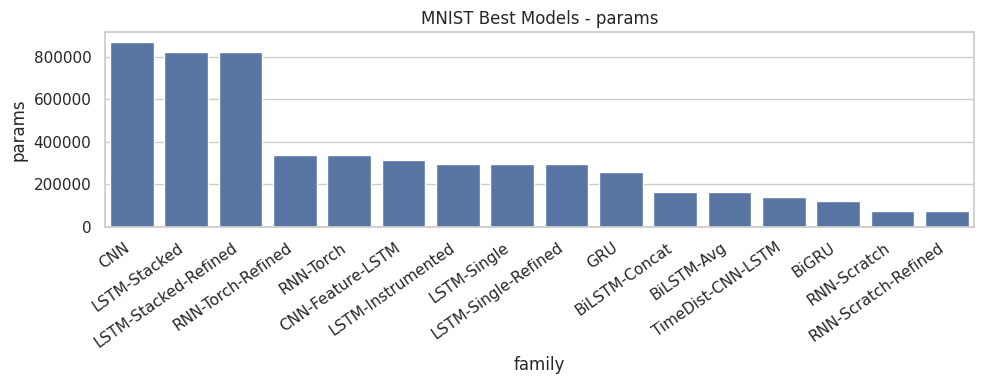

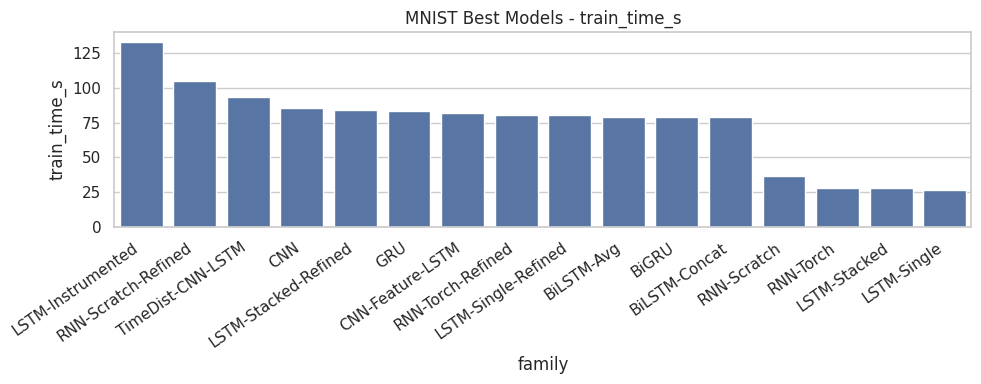

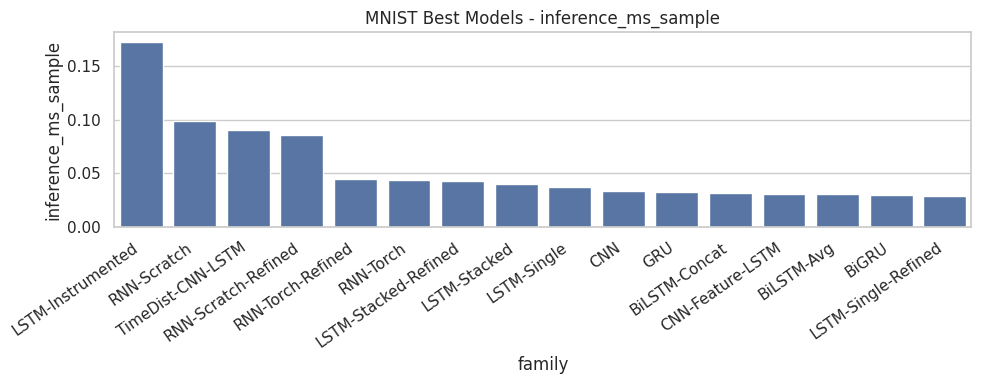

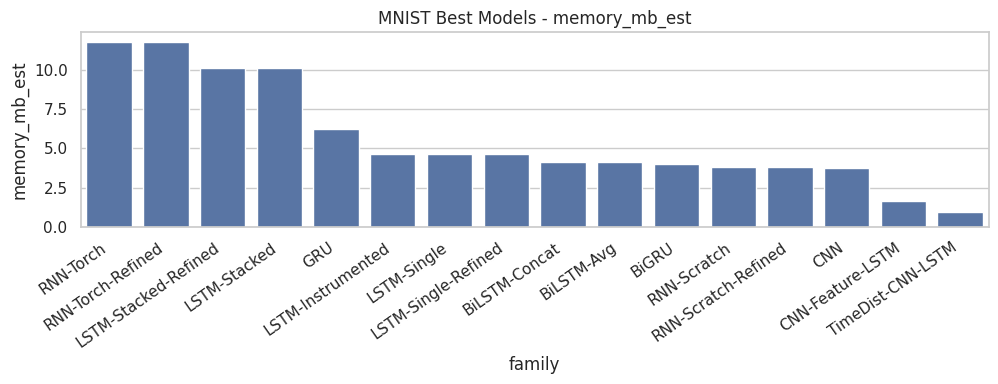

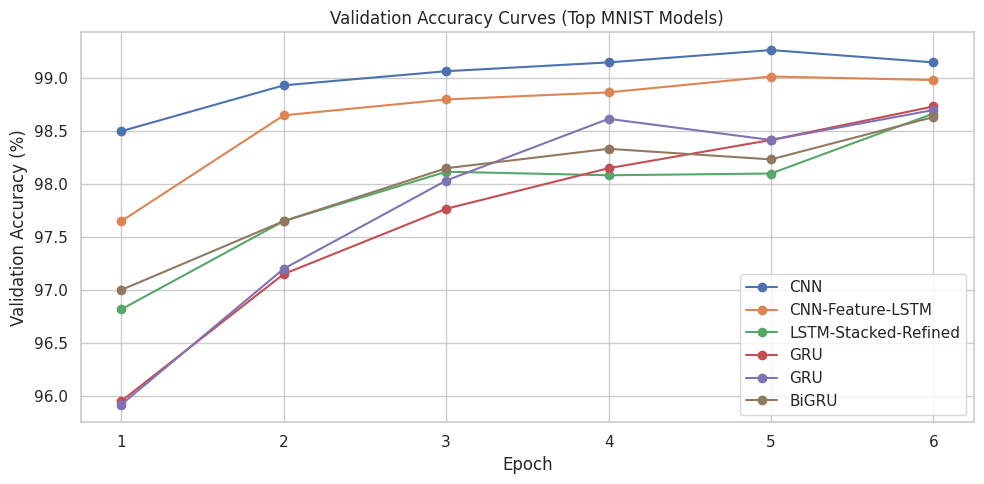

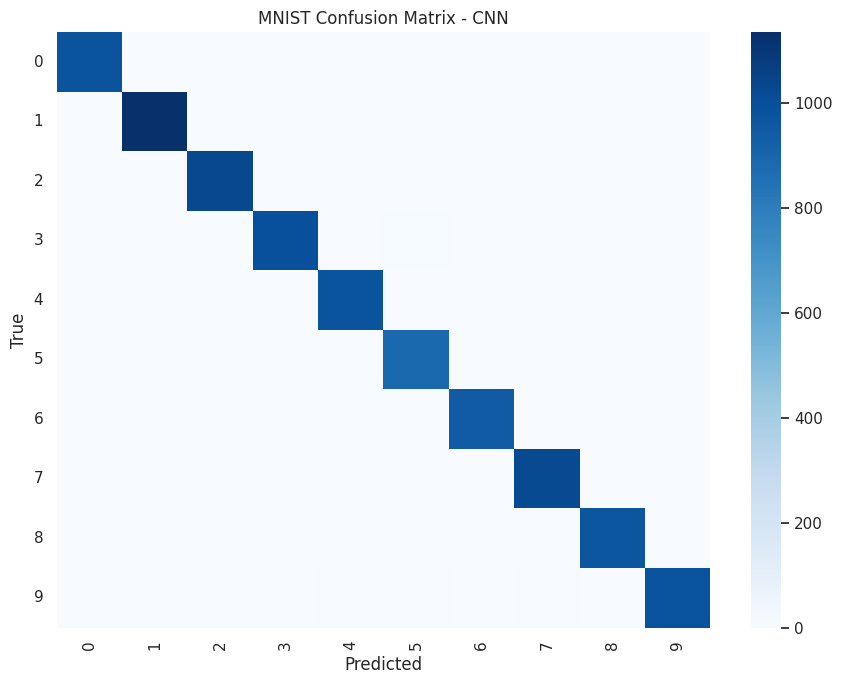

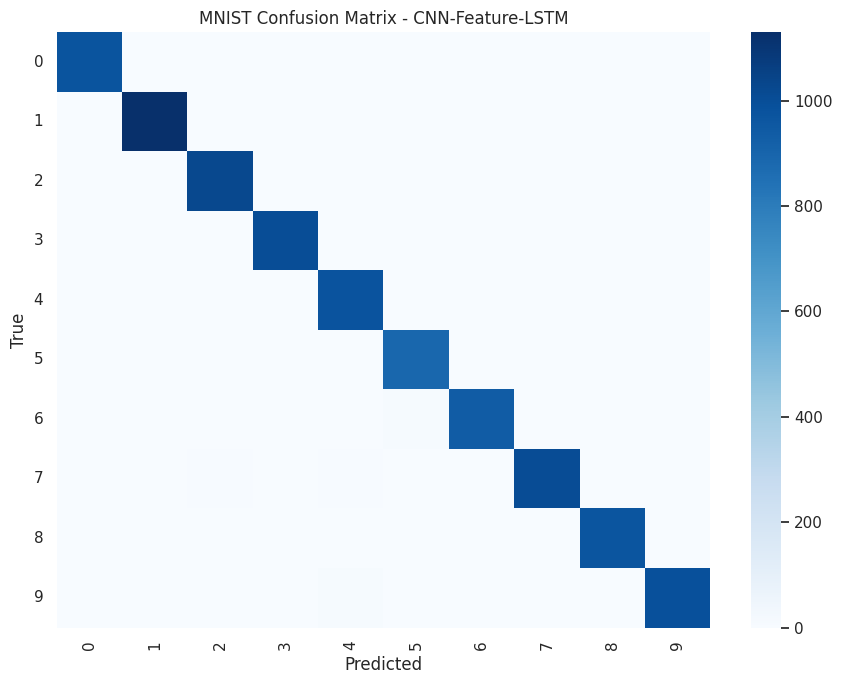

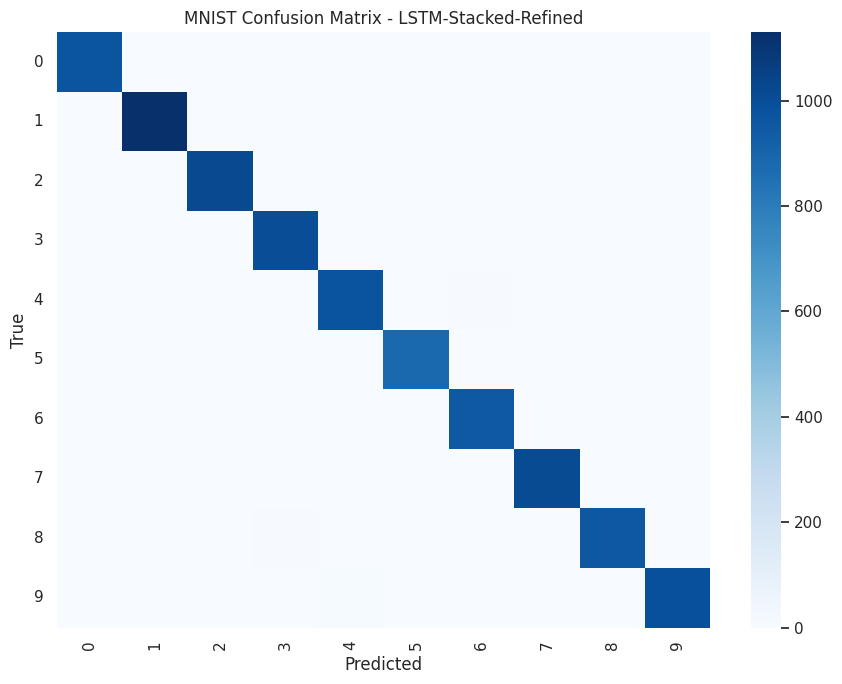

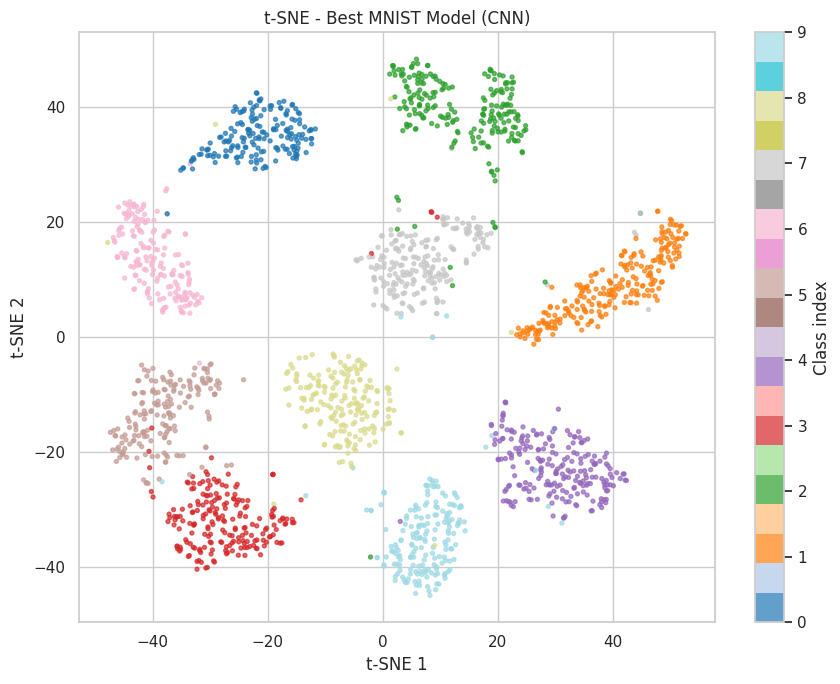

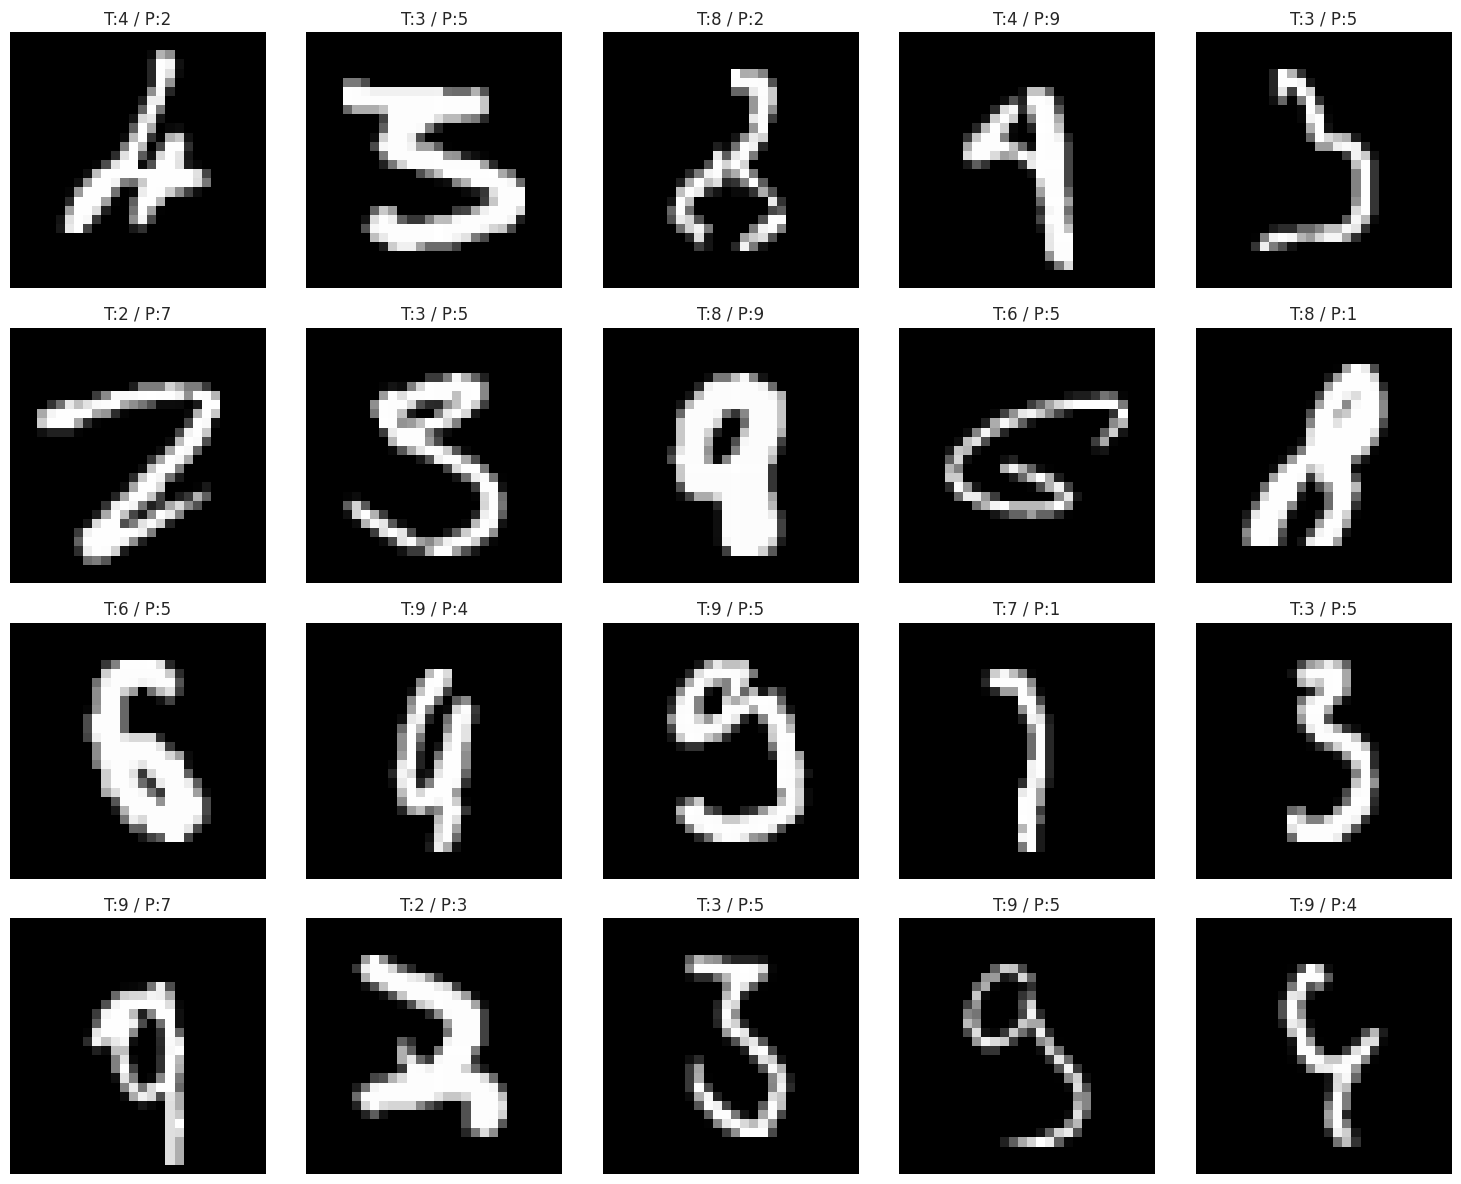

Classification report for best MNIST model:
              precision    recall  f1-score   support

           0     0.9980    0.9990    0.9985       980
           1     0.9904    1.0000    0.9952      1135
           2     0.9952    0.9971    0.9961      1032
           3     0.9990    0.9851    0.9920      1010
           4     0.9939    0.9939    0.9939       982
           5     0.9737    0.9978    0.9856       892
           6     0.9979    0.9885    0.9932       958
           7     0.9932    0.9951    0.9942      1028
           8     0.9928    0.9938    0.9933       974
           9     0.9950    0.9792    0.9870      1009

    accuracy                         0.9930     10000
   macro avg     0.9929    0.9930    0.9929     10000
weighted avg     0.9931    0.9930    0.9930     10000

Problem 7 completed.


In [10]:
# Optional cross-dataset benchmark on EMNIST for representative model families
emnist_benchmark_specs = {
    "EMNIST-RNN": {
        "builder": lambda nc: TorchRNNClassifier(input_size=28, hidden_size=128, num_layers=2, num_classes=nc, dropout=0.2),
        "input_mode": "sequence_row",
        "meta": {"cell_type": "rnn", "seq_len": 28, "input_size": 28, "hidden_size": 128, "num_layers": 2, "bidirectional": False},
    },
    "EMNIST-LSTM": {
        "builder": lambda nc: StackedLSTMClassifier(input_size=28, hidden_size=128, num_layers=2, num_classes=nc, dropout=0.3),
        "input_mode": "sequence_row",
        "meta": {"cell_type": "lstm", "seq_len": 28, "input_size": 28, "hidden_size": 128, "num_layers": 2, "bidirectional": False},
    },
    "EMNIST-GRU": {
        "builder": lambda nc: GRUClassifier(input_size=28, hidden_size=128, num_layers=2, num_classes=nc, dropout=0.3),
        "input_mode": "sequence_row",
        "meta": {"cell_type": "gru", "seq_len": 28, "input_size": 28, "hidden_size": 128, "num_layers": 2, "bidirectional": False},
    },
    "EMNIST-BiLSTM": {
        "builder": lambda nc: BiLSTMConcatClassifier(input_size=28, hidden_size=128, num_layers=1, num_classes=nc, dropout=0.3),
        "input_mode": "sequence_row",
        "meta": {"cell_type": "lstm", "seq_len": 28, "input_size": 28, "hidden_size": 128, "num_layers": 1, "bidirectional": True},
    },
    "EMNIST-CNN": {
        "builder": lambda nc: CNNBaseline(num_classes=nc, dropout=0.3),
        "input_mode": "image",
        "meta": {"cell_type": "cnn", "seq_len": 1, "input_size": 1, "hidden_size": 256, "num_layers": 1, "bidirectional": False, "cnn_flops": 8e6},
    },
    "EMNIST-CNN-LSTM": {
        "builder": lambda nc: CNNFeatureLSTM(num_classes=nc, hidden_size=128, num_layers=1, dropout=0.3),
        "input_mode": "image",
        "meta": {"cell_type": "lstm", "seq_len": 7, "input_size": 64 * 7, "hidden_size": 128, "num_layers": 1, "bidirectional": False, "cnn_flops": 1.2e7},
    },
}

emnist_rows = []
for fam, spec in tqdm(emnist_benchmark_specs.items(), desc="EMNIST Benchmarks"):
    model = spec["builder"](DATASETS["EMNIST"]["num_classes"]).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=CONFIG.lr_default, weight_decay=CONFIG.weight_decay_default)

    if spec["input_mode"] == "image":
        loaders = EMNIST_LOADERS["image"]
    else:
        loaders = EMNIST_LOADERS["sequence"]["row"]

    row, hist, _ = run_experiment(
        model=model,
        experiment_name=f"P7_{fam}",
        family=fam,
        problem="P7",
        dataset_name="EMNIST",
        loaders=loaders,
        input_mode=spec["input_mode"],
        optimizer=optimizer,
        criterion=criterion,
        epochs=max(1, CONFIG.epochs_screen),
        lr=CONFIG.lr_default,
        weight_decay=CONFIG.weight_decay_default,
        scheduler=None,
        grad_clip=CONFIG.grad_clip_default,
        early_stopping=None,
        capture_grads=False,
        meta={**spec["meta"], "num_classes": DATASETS["EMNIST"]["num_classes"]},
        verbose=False,
    )
    emnist_rows.append(row)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

emnist_df = pd.DataFrame(emnist_rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
print("EMNIST benchmark summary:")
print(emnist_df[["family", "test_acc", "train_time_s", "params", "inference_ms_sample"]])


# Aggregate all experiments
results_df = pd.DataFrame(EXPERIMENT_RESULTS)
results_df = results_df.sort_values("test_acc", ascending=False).reset_index(drop=True)
print(f"Total experiment runs logged: {len(results_df)}")

# Filter noisy utility runs from the final architecture comparison
mask_exclude = results_df["family"].str.contains("Viz|GradAnalysis|Tuning", na=False)
arch_df = results_df[~mask_exclude].copy()

# Best run per (dataset, family)
best_per_family = (
    arch_df.sort_values("test_acc", ascending=False)
    .groupby(["dataset", "family"], as_index=False)
    .first()
)

# Final comparison table with required metrics
final_cols = [
    "dataset",
    "family",
    "test_acc",
    "params",
    "train_time_s",
    "inference_ms_sample",
    "memory_mb_est",
    "convergence_epoch",
]

print("\nFinal comparison table (best run per family):")
print(best_per_family[final_cols].sort_values(["dataset", "test_acc"], ascending=[True, False]))

# Bar charts for core metrics
mnist_best = best_per_family[best_per_family["dataset"] == "MNIST"].copy()
plot_metrics = ["test_acc", "params", "train_time_s", "inference_ms_sample", "memory_mb_est"]
for metric in plot_metrics:
    plt.figure(figsize=(10, 4))
    sns.barplot(data=mnist_best.sort_values(metric, ascending=False), x="family", y=metric)
    plt.title(f"MNIST Best Models - {metric}")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

# Combined training curve comparison for top MNIST models
top_mnist = arch_df[arch_df["dataset"] == "MNIST"].sort_values("test_acc", ascending=False).head(6)
plt.figure(figsize=(10, 5))
for _, row in top_mnist.iterrows():
    exp = row["experiment"]
    hist = HISTORIES.get(exp)
    if hist is None:
        continue
    vals = np.array(hist["val_acc"]) * 100
    plt.plot(range(1, len(vals) + 1), vals, marker="o", label=row["family"])
plt.title("Validation Accuracy Curves (Top MNIST Models)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


def get_test_loader_for_input_mode(dataset_name, input_mode, batch_size=256):
    loaders = get_loaders(dataset_name, batch_size=batch_size)
    if input_mode == "image":
        return loaders["image"]["test"]
    if input_mode == "sequence_row":
        return loaders["sequence"]["row"]["test"]
    if input_mode == "sequence_col":
        return loaders["sequence"]["col"]["test"]
    # fallback
    return loaders["sequence"]["row"]["test"]


# Confusion matrices for top 3 MNIST families
top3_mnist = mnist_best.sort_values("test_acc", ascending=False).head(3)
for _, row in top3_mnist.iterrows():
    family = row["family"]
    key = ("MNIST", family)
    if key not in BEST_MODELS:
        continue

    info = BEST_MODELS[key]
    model = info["model"].to(DEVICE)
    model.eval()

    test_loader = get_test_loader_for_input_mode("MNIST", info["input_mode"], batch_size=256)
    ev = evaluate_model(model, test_loader, criterion, device=DEVICE, return_preds=True)

    plot_confusion(
        ev["targets"],
        ev["preds"],
        DATASETS["MNIST"]["class_names"],
        title=f"MNIST Confusion Matrix - {family}",
    )

    model.cpu()
    del model
    gc.collect()

# t-SNE and misclassified samples using best overall MNIST model
if len(mnist_best) > 0:
    best_row = mnist_best.sort_values("test_acc", ascending=False).iloc[0]
    best_family = best_row["family"]
    key = ("MNIST", best_family)
    if key in BEST_MODELS:
        best_info = BEST_MODELS[key]
        best_model = best_info["model"].to(DEVICE)
        input_mode = best_info["input_mode"]
        test_loader = get_test_loader_for_input_mode("MNIST", input_mode, batch_size=256)

        tsne_feature_plot(
            model=best_model,
            loader=test_loader,
            class_names=DATASETS["MNIST"]["class_names"],
            input_mode=input_mode,
            max_points=2000,
            title=f"t-SNE - Best MNIST Model ({best_family})",
        )

        display_misclassified_samples(
            model=best_model,
            loader=test_loader,
            class_names=DATASETS["MNIST"]["class_names"],
            n=20,
            input_mode=input_mode,
        )

        # Compact classification report
        rep_eval = evaluate_model(best_model, test_loader, criterion, device=DEVICE, return_preds=True)
        print("Classification report for best MNIST model:")
        print(classification_report(rep_eval["targets"], rep_eval["preds"], digits=4))

        best_model.cpu()
        del best_model
        gc.collect()

print("Problem 7 completed.")

## 10) Conclusions

This notebook implemented and compared recurrent and hybrid architectures for handwritten character recognition with complete training/evaluation pipelines on MNIST and EMNIST.

### Key takeaways to report in your lab submission

- Vanilla RNNs are simple but can suffer from gradient attenuation for deeper stacks.
- LSTM/GRU improve long-range sequence handling, with GRU often providing a favorable efficiency/accuracy trade-off.
- Bidirectional sequence models can improve contextual learning at additional compute cost.
- CNN-LSTM hybrids effectively combine local spatial feature extraction with temporal modeling.
- Hyperparameter choices (optimizer, LR, batch size) significantly affect convergence and final accuracy.

The notebook is structured for reproducible experimentation and can be extended for additional architectures (e.g., ConvLSTM or attention-based sequence models).